<a href="https://colab.research.google.com/github/whosphong/DATA-STRUCTURES-AND-PLATFORMS---UAmath509/blob/main/509_PROJ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Winter 2025 MATH 509 PROJECT

- Phong Ho
- Michael Zhang
- R.J. Bilak
- Edmond Tuong

------------------------

### Packages

In [128]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import DBSCAN
import scipy.stats as stats
import matplotlib as mpl
import datetime, nltk, warnings
import matplotlib.cm as cm
from scipy.stats.mstats import winsorize
import itertools
from pathlib import Path
from sklearn.metrics import silhouette_samples, silhouette_score, confusion_matrix
from sklearn import preprocessing, model_selection, metrics, feature_selection
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.svm import SVC
from sklearn import neighbors, linear_model, svm, tree, ensemble
from sklearn.ensemble import AdaBoostClassifier
from sklearn.decomposition import PCA
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from IPython.display import display, HTML
import plotly.graph_objs as go
from plotly.offline import init_notebook_mode, iplot
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap
import sys
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from matplotlib.colors import BoundaryNorm

if not sys.warnoptions:
    warnings.simplefilter("ignore")
np.random.seed(42)

init_notebook_mode(connected=True)
warnings.filterwarnings("ignore")
plt.rcParams["patch.force_edgecolor"] = True
plt.style.use('fivethirtyeight')
mpl.rc('patch', edgecolor='dimgray', linewidth=1)
%matplotlib inline


In [9]:
palette = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22"]

sns.set_palette(palette)

# EDA / Preprocessing

-------------------

In [2]:
data = 'https://raw.githubusercontent.com/whosphong/DATA-STRUCTURES-AND-PLATFORMS---UAmath509/refs/heads/main/google_review_ratings.csv'
df = pd.read_csv(data)

In [4]:
df.head(5)

,User,Category 1,Category 2,Category 3,Category 4,Category 5,Category 6,Category 7,Category 8,Category 9,...,Category 16,Category 17,Category 18,Category 19,Category 20,Category 21,Category 22,Category 23,Category 24,Unnamed: 25
0,User 1,0.0,0.0,3.63,3.65,5.0,2.92,5.0,2.35,2.33,...,0.59,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0,NaN
1,User 2,0.0,0.0,3.63,3.65,5.0,2.92,5.0,2.64,2.33,...,0.59,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0,NaN
2,User 3,0.0,0.0,3.63,3.63,5.0,2.92,5.0,2.64,2.33,...,0.59,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0,NaN
3,User 4,0.0,0.5,3.63,3.63,5.0,2.92,5.0,2.35,2.33,...,0.59,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0,NaN
4,User 5,0.0,0.0,3.63,3.63,5.0,2.92,5.0,2.64,2.33,...,0.59,0.5,0.0,0.5,0.0,0.0,0.0,0.0,0.0,NaN


In [5]:
## Checking types of Data

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5454 entries, 0 to 5453
Data columns (total 26 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   User         5454 non-null   object 
 1   Category 1   5454 non-null   float64
 2   Category 2   5454 non-null   float64
 3   Category 3   5454 non-null   float64
 4   Category 4   5454 non-null   float64
 5   Category 5   5454 non-null   float64
 6   Category 6   5454 non-null   float64
 7   Category 7   5454 non-null   float64
 8   Category 8   5454 non-null   float64
 9   Category 9   5454 non-null   float64
 10  Category 10  5454 non-null   float64
 11  Category 11  5454 non-null   float64
 12  Category 12  5454 non-null   float64
 13  Category 13  5454 non-null   float64
 14  Category 14  5454 non-null   float64
 15  Category 15  5454 non-null   float64
 16  Category 16  5454 non-null   float64
 17  Category 17  5454 non-null   float64
 18  Category 18  5454 non-null   float64
 19  Catego

In [6]:
df.describe()

,Category 1,Category 2,Category 3,Category 4,Category 5,Category 6,Category 7,Category 8,Category 9,Category 10,...,Category 16,Category 17,Category 18,Category 19,Category 20,Category 21,Category 22,Category 23,Category 24,Unnamed: 25
count,5454.000000,5454.000000,5454.000000,5454.000000,5454.000000,5454.000000,5454.000000,5454.000000,5454.000000,5454.000000,...,5454.000000,5454.000000,5454.000000,5454.000000,5454.000000,5454.000000,5454.000000,5454.000000,5454.000000,0.0
mean,1.455746,2.320048,2.489059,2.797103,2.958904,2.893423,3.351476,2.541177,3.126542,2.832695,...,1.192710,0.949349,0.822525,0.969250,0.999626,0.965275,1.749345,1.531051,1.560570,NaN
std,0.827732,1.421576,1.247503,1.309188,1.338785,1.282101,1.413291,1.111398,1.356774,1.307299,...,1.107176,0.973628,0.948015,1.202883,1.193129,0.928326,1.597816,1.316180,1.171784,NaN
min,0.000000,0.000000,0.000000,0.830000,1.120000,1.110000,1.120000,0.860000,0.840000,0.810000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN
25%,0.920000,1.360000,1.540000,1.730000,1.770000,1.790000,1.930000,1.620000,1.800000,1.640000,...,0.690000,0.580000,0.530000,0.520000,0.540000,0.570000,0.740000,0.790000,0.880000,NaN
50%,1.340000,1.910000,2.060000,2.460000,2.670000,2.680000,3.230000,2.170000,2.800000,2.680000,...,0.800000,0.740000,0.690000,0.690000,0.690000,0.760000,1.030000,1.070000,1.290000,NaN
75%,1.810000,2.687500,2.740000,4.097500,4.310000,3.837500,5.000000,3.190000,5.000000,3.527500,...,1.160000,0.910000,0.840000,0.860000,0.860000,1.000000,2.070000,1.560000,1.660000,NaN
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,NaN


In [7]:
df.drop(columns=['User', 'Unnamed: 25'], inplace=True)

In [8]:
df = df.rename(columns = {
    "Category 1": "churches", 
    "Category 2": "resorts", 
    "Category 3": "beaches", 
    "Category 4": "parks", 
    "Category 5": "theatres",
    "Category 6": "museums", 
    "Category 7": "malls", 
    "Category 8": "zoos", 
    "Category 9": "restaurants", 
    "Category 10": "pubs", 
    "Category 11": "services", 
    "Category 12": "pizzerias", 
    "Category 13": "hotels", 
    "Category 14": "refreshments", 
    "Category 15": "galleries", 
    "Category 16": "clubs", 
    "Category 17": "pools", 
    "Category 18": "gyms", 
    "Category 19": "bakeries", 
    "Category 20": "spas", 
    "Category 21": "cafes", 
    "Category 22": "panorama", 
    "Category 23": "monuments", 
    "Category 24": "gardens"
}).copy()


Relative Plot Of Some Selected Features: A Data Subset


<Figure size 1500x1000 with 0 Axes>

<Figure size 800x550 with 0 Axes>

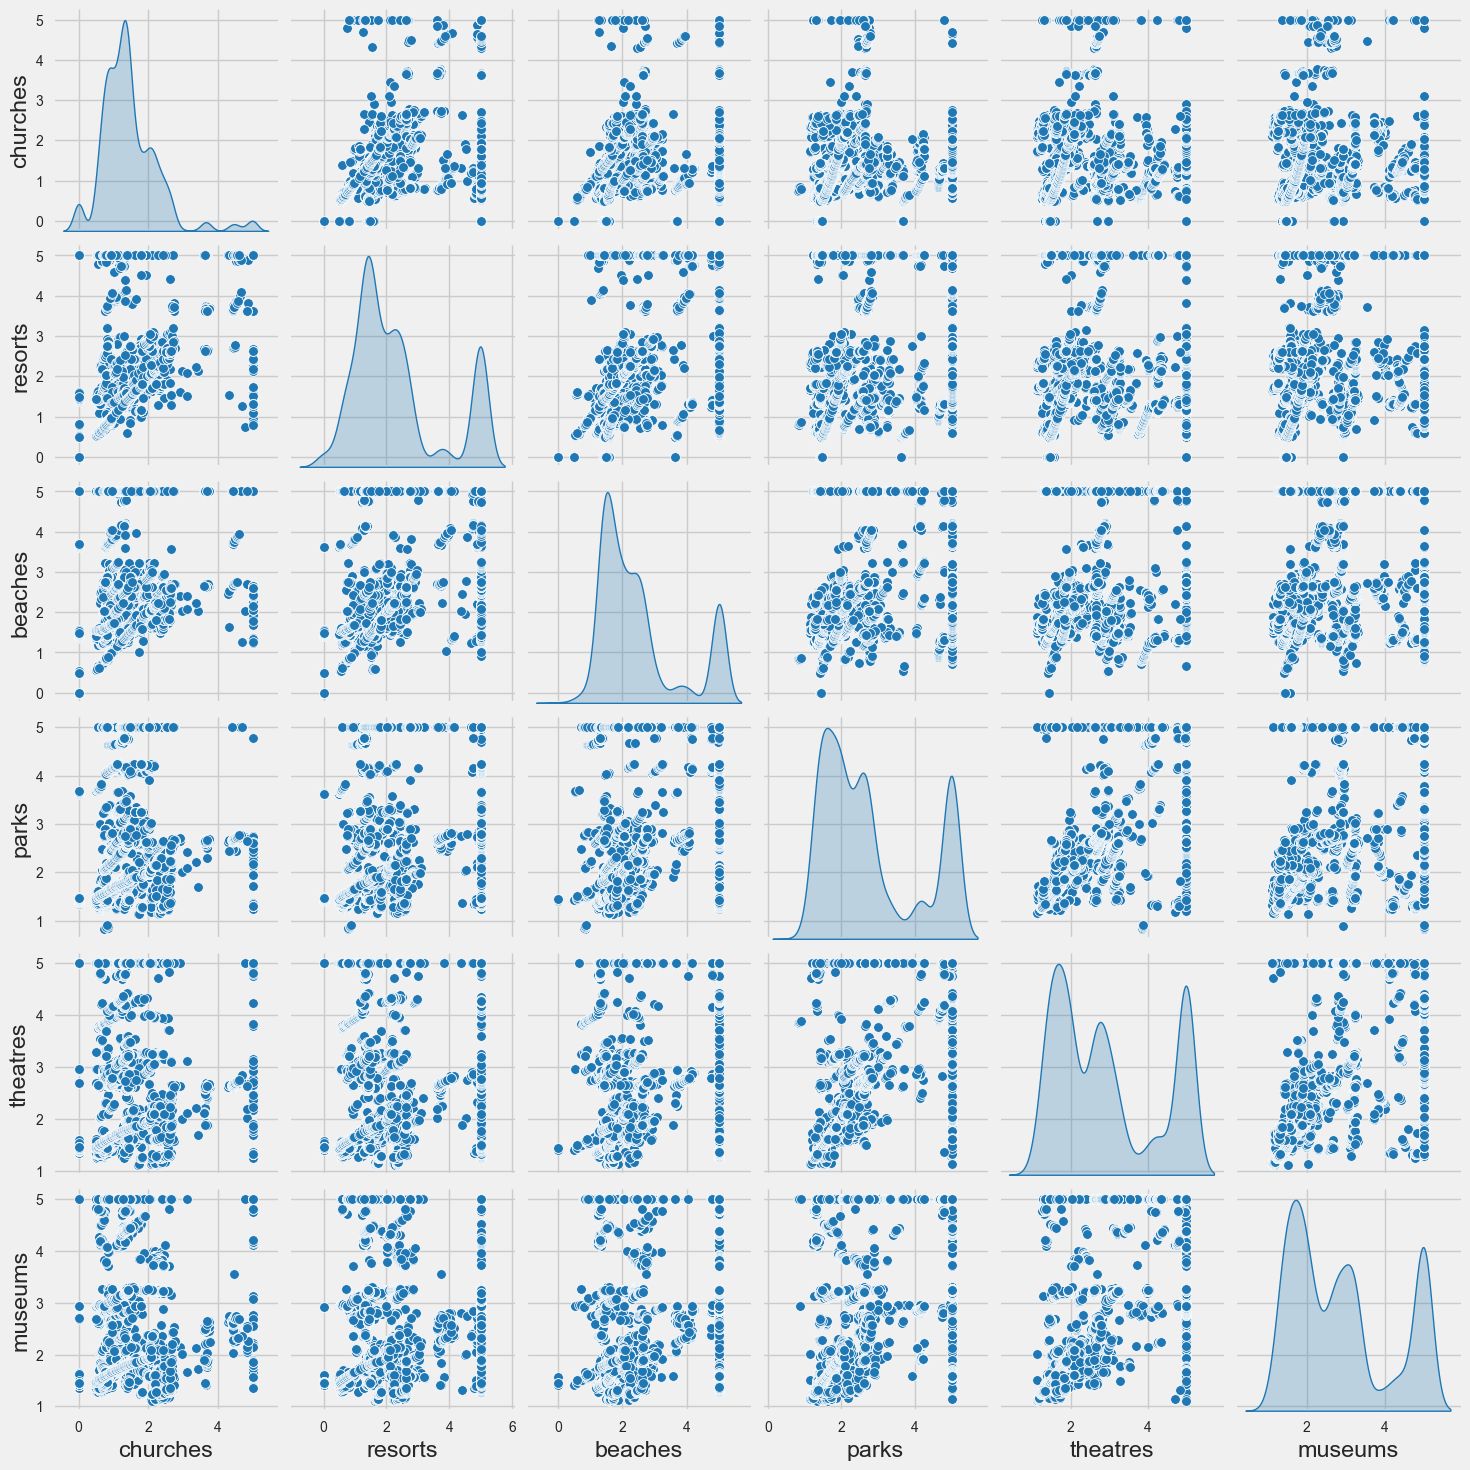

In [ ]:

To_Plot = ["churches", "resorts", "beaches", "parks", "theatres", "museums"]

print("Relative Plot Of Some Selected Features: A Data Subset")

plt.figure()
sns.pairplot(df[To_Plot], diag_kind="kde")
plt.show()


In [10]:
df.isna().sum() ## None


churches        0
resorts         0
beaches         0
parks           0
theatres        0
museums         0
malls           0
zoos            0
restaurants     0
pubs            0
services        0
pizzerias       0
hotels          0
refreshments    0
galleries       0
clubs           0
pools           0
gyms            0
bakeries        0
spas            0
cafes           0
panorama        0
monuments       0
gardens         0
dtype: int64

In [11]:
dup_df = df[df.duplicated(keep=False)] ## Indicates 2 == 4, 670 == 674, 1338 == 1346
dup_df


,churches,resorts,beaches,parks,theatres,museums,malls,zoos,restaurants,pubs,...,galleries,clubs,pools,gyms,bakeries,spas,cafes,panorama,monuments,gardens
2,0.00,0.0,3.63,3.63,5.00,2.92,5.00,2.64,2.33,2.64,...,1.74,0.59,0.5,0.0,0.50,0.0,0.0,0.00,0.00,0.00
4,0.00,0.0,3.63,3.63,5.00,2.92,5.00,2.64,2.33,2.64,...,1.74,0.59,0.5,0.0,0.50,0.0,0.0,0.00,0.00,0.00
670,0.00,0.0,1.45,1.43,1.42,1.43,1.48,1.48,2.72,2.73,...,5.00,0.81,0.8,5.0,0.92,0.0,0.0,0.00,0.00,0.00
674,0.00,0.0,1.45,1.43,1.42,1.43,1.48,1.48,2.72,2.73,...,5.00,0.81,0.8,5.0,0.92,0.0,0.0,0.00,0.00,0.00
1338,1.06,1.1,5.00,3.28,5.00,5.00,5.00,1.84,1.81,5.00,...,1.77,1.80,0.0,0.0,0.00,0.0,0.0,1.05,1.03,1.04
1346,1.06,1.1,5.00,3.28,5.00,5.00,5.00,1.84,1.81,5.00,...,1.77,1.80,0.0,0.0,0.00,0.0,0.0,1.05,1.03,1.04


In [12]:
df.drop_duplicates(inplace=True)

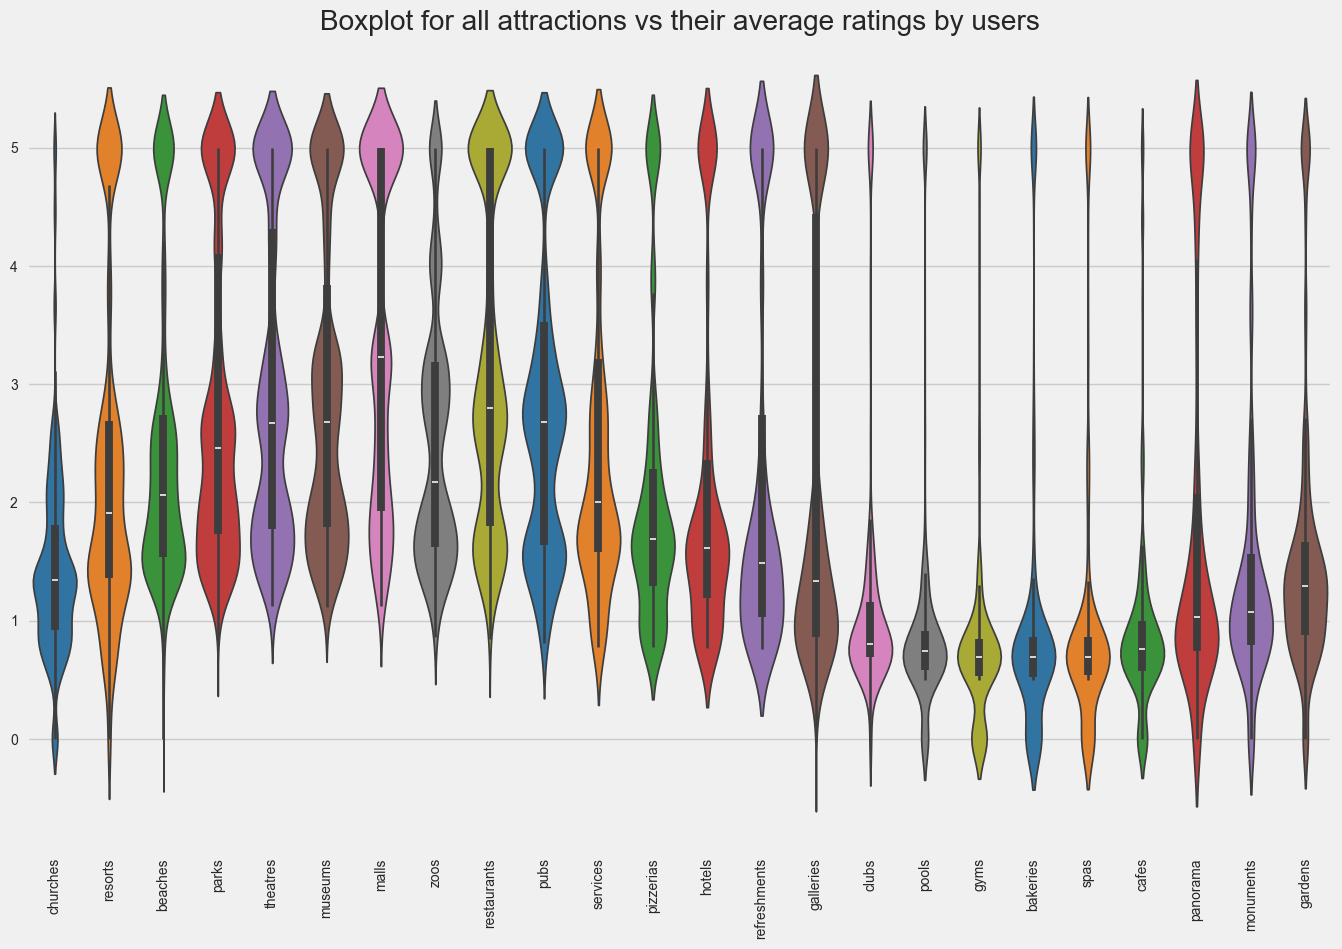

In [14]:
plt.figure(figsize=(15, 10))
sns.violinplot(data=df, palette=palette)
plt.xticks(rotation=90)
plt.title('Boxplot for all attractions vs their average ratings by users')
plt.show()


In [16]:
# Q1 = df.quantile(0.25)
# Q3 = df.quantile(0.75)
# IQR = Q3 - Q1
# print(IQR)

# #df = df[~((df < (Q1 - 1.5 * IQR)) |(df > (Q3 + 1.5 * IQR))).any(axis=1)] ## Removing Outliers

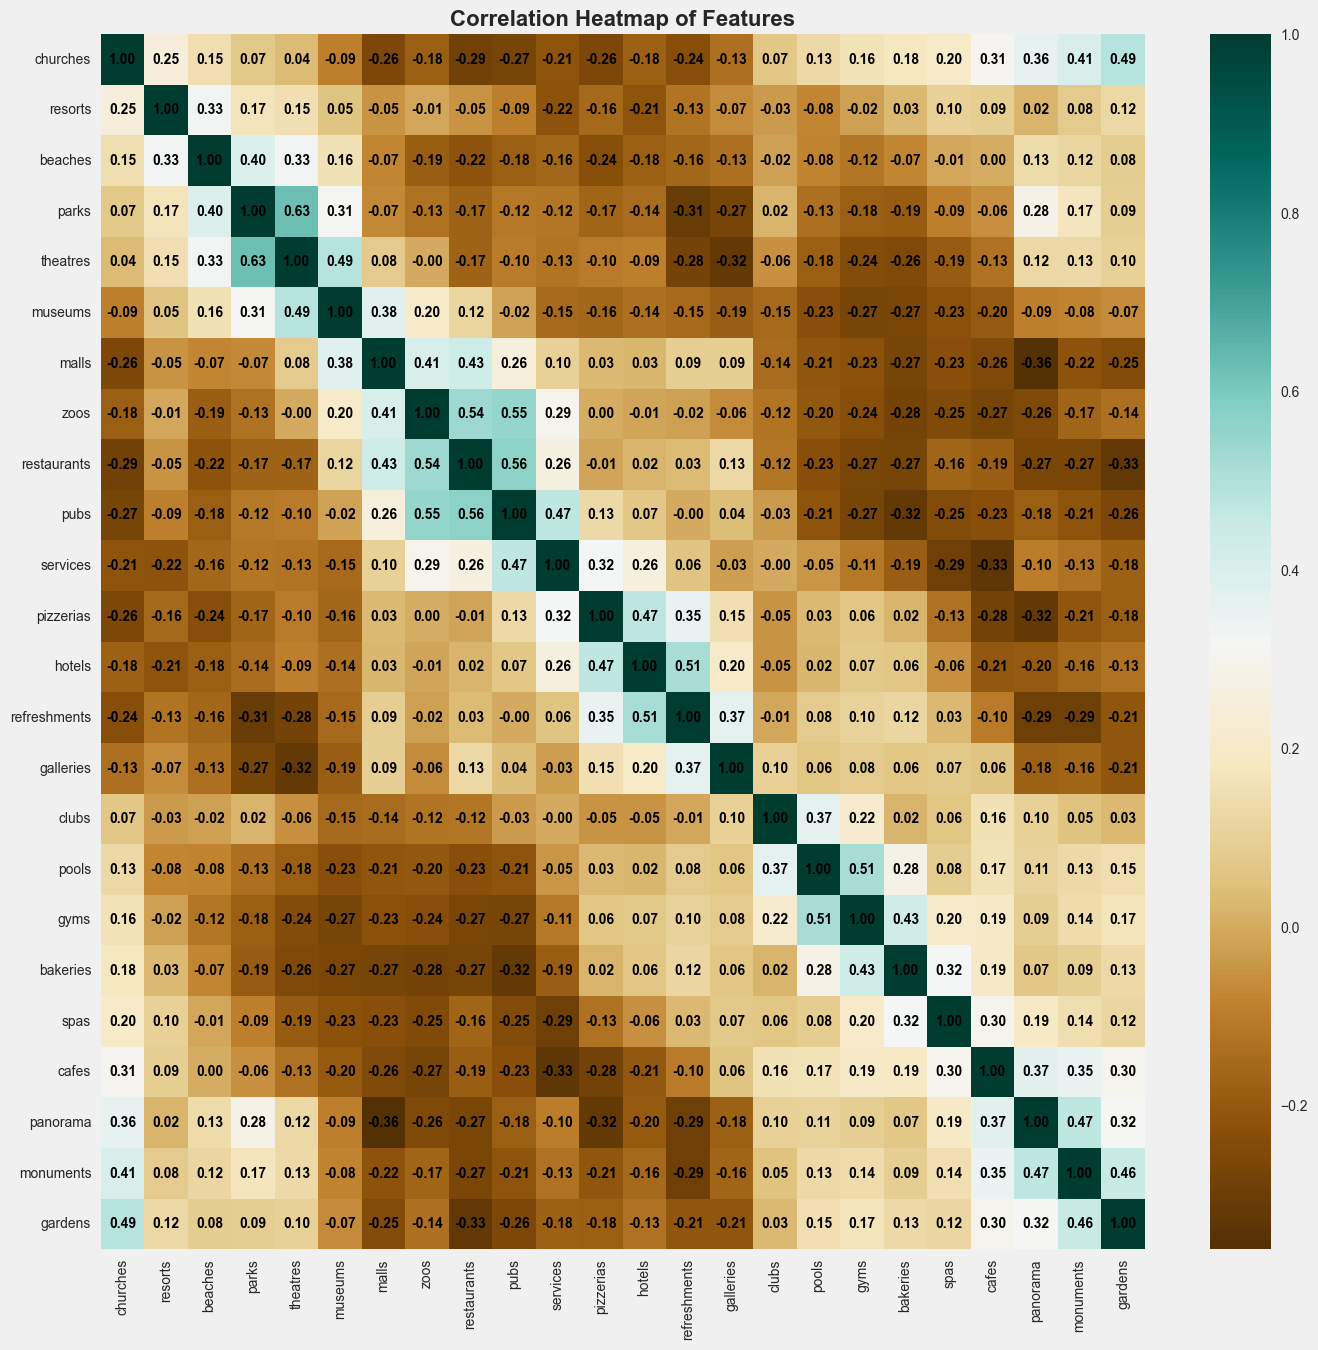

In [15]:
plt.figure(figsize=(15, 15))
c = df.corr()
sns.heatmap(c, cmap="BrBG", annot=True, fmt=".2f", annot_kws={"size": 10, "weight": "bold", "color": "black"})
plt.title("Correlation Heatmap of Features", fontsize=16, weight="bold")
plt.show()

In [12]:
c[c==1] = 0
maxcorrs = pd.DataFrame()
maxcorrs["Max Correlation"] = np.max(abs(c), axis=0)
maxcorrs["With"] = np.argmax(abs(c), axis=0)+1
maxcorrs

# Correlations seem not high enough to justify removing any

,Max Correlation,With
churches,0.489249,24
resorts,0.325429,3
beaches,0.396694,4
parks,0.626787,5
theatres,0.626787,4
museums,0.489528,5
malls,0.432183,9
zoos,0.551613,10
restaurants,0.564442,10
pubs,0.564442,9


In [17]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
scaled_ds = pd.DataFrame(df_scaled, columns=df.columns)

In [18]:
scaled_ds.head(5)

,churches,resorts,beaches,parks,theatres,museums,malls,zoos,restaurants,pubs,...,galleries,clubs,pools,gyms,bakeries,spas,cafes,panorama,monuments,gardens
0,-1.760164,-1.633391,0.915264,0.651441,1.525493,0.020829,1.166893,-0.172279,-0.587392,-0.147147,...,-0.271485,-0.544365,-0.461778,-0.868648,-0.390289,-0.838288,-1.040493,-1.095377,-1.163841,-1.332573
1,-1.760164,-1.633391,0.915264,0.651441,1.525493,0.020829,1.166893,0.088638,-0.587392,-0.139497,...,-0.271485,-0.544365,-0.461778,-0.868648,-0.390289,-0.838288,-1.040493,-1.095377,-1.163841,-1.332573
2,-1.760164,-1.633391,0.915264,0.636165,1.525493,0.020829,1.166893,0.088638,-0.587392,-0.147147,...,-0.271485,-0.544365,-0.461778,-0.868648,-0.390289,-0.838288,-1.040493,-1.095377,-1.163841,-1.332573
3,-1.760164,-1.281537,0.915264,0.636165,1.525493,0.020829,1.166893,-0.172279,-0.587392,-0.147147,...,-0.271485,-0.544365,-0.461778,-0.868648,-0.390289,-0.838288,-1.040493,-1.095377,-1.163841,-1.332573
4,-1.760164,-1.633391,0.915264,0.636165,1.525493,0.020829,1.166893,0.079640,-0.587392,-0.139497,...,-0.271485,-0.544365,-0.461778,-0.868648,-0.390289,-0.838288,-1.040493,-1.095377,-1.163841,-1.332573


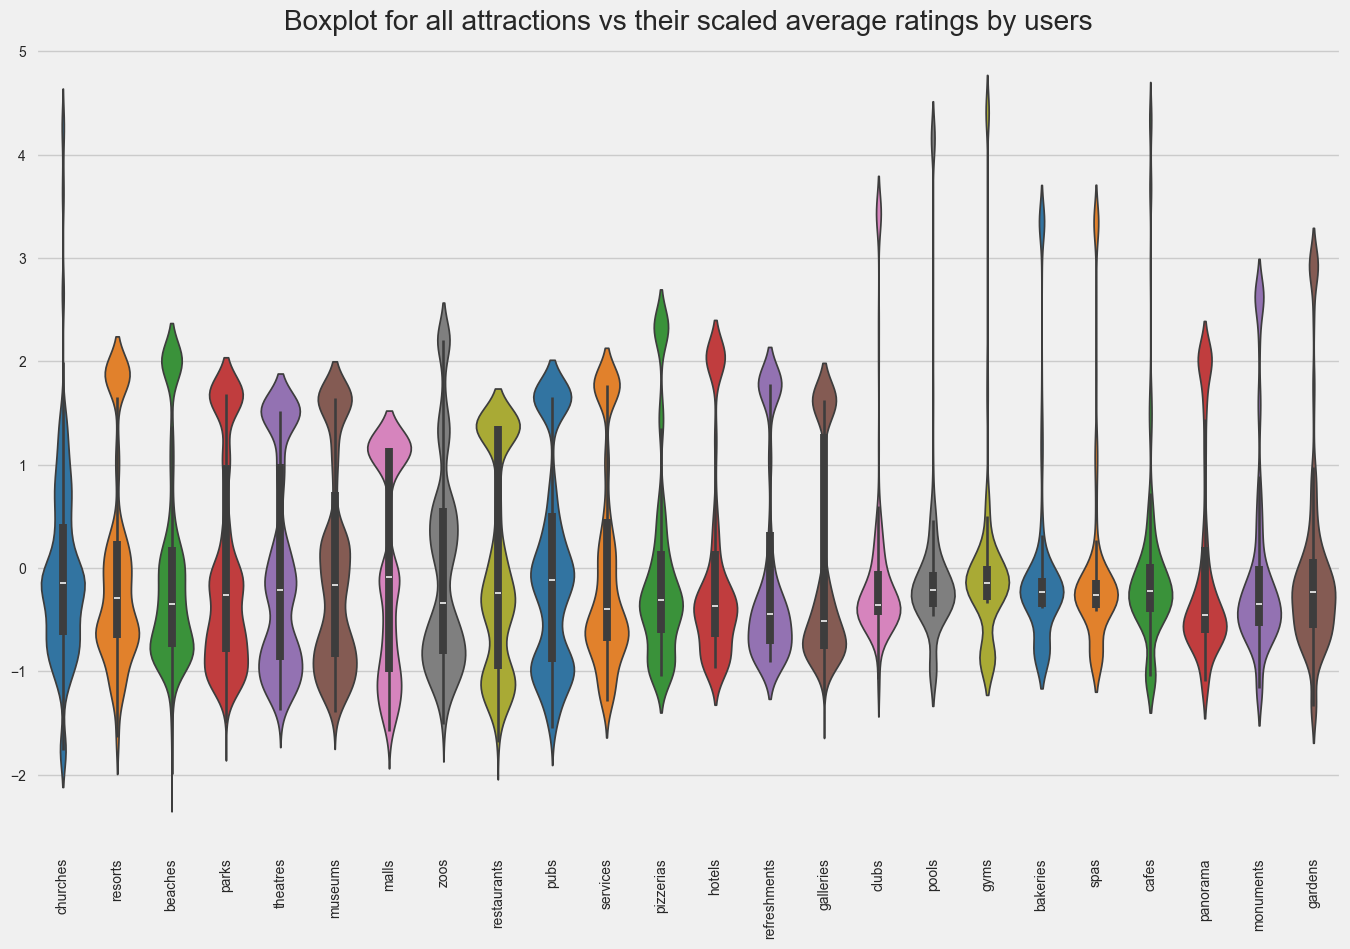

In [25]:
plt.figure(figsize=(15, 10))
sns.violinplot(data=scaled_ds, palette=palette)
plt.xticks(rotation=90)
plt.title('Boxplot for all attractions vs their scaled average ratings by users')
plt.show()


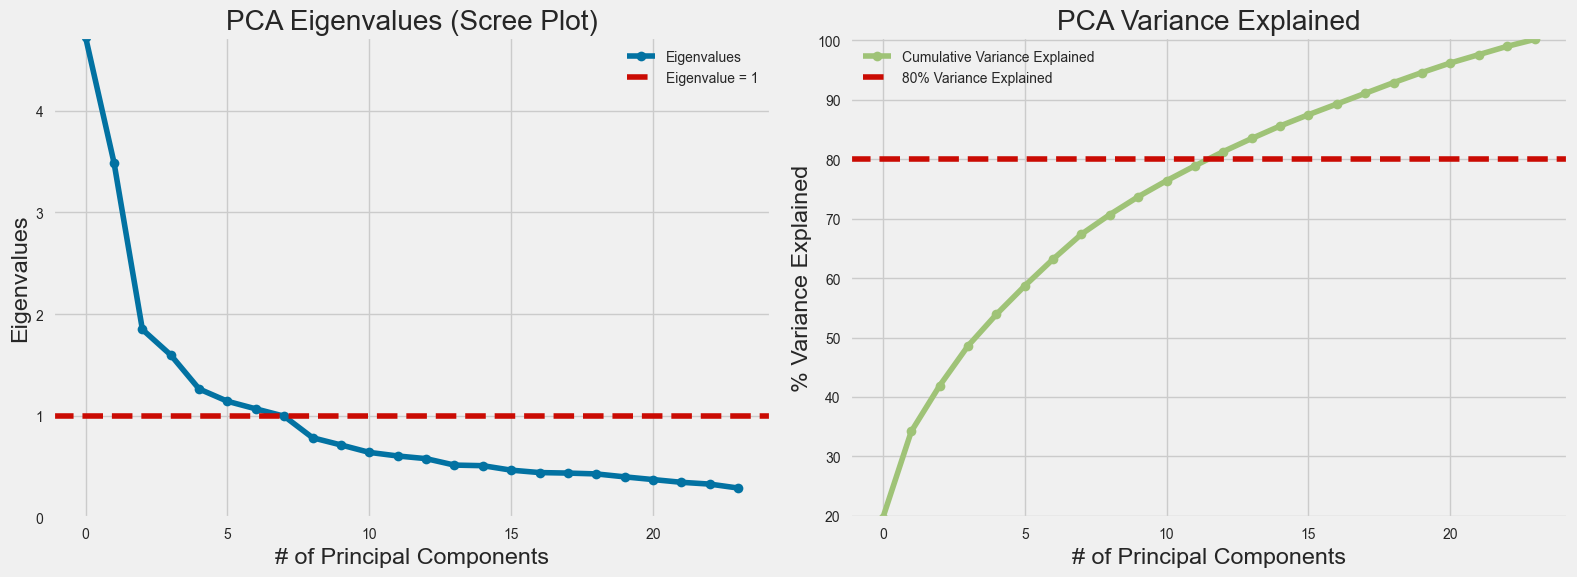

In [ ]:


# Fit PCA model
pca = PCA(n_components=len(scaled_ds.columns))  # Number of components equals the number of features
pca.fit(scaled_ds)

# Create a 1x2 grid of subplots
fig, ax = plt.subplots(1, 2, figsize=(16, 6))  # 1 row, 2 columns

# --- Eigenvalue Plot (Scree Plot) ---
ax[0].set_ylabel('Eigenvalues')
ax[0].set_xlabel('# of Principal Components')
ax[0].set_title('PCA Eigenvalues (Scree Plot)')
ax[0].set_ylim(0, max(pca.explained_variance_))  # Set the y-axis limit to the max eigenvalue
ax[0].plot(pca.explained_variance_, marker='o', linestyle='-', color='b', label='Eigenvalues')
ax[0].axhline(y=1, color='r', linestyle='--', label='Eigenvalue = 1')  # Threshold line
ax[0].legend(loc='best')

# --- Variance Explained Plot ---
variance = pca.explained_variance_ratio_  # Calculate variance ratios
var = np.cumsum(np.round(variance, decimals=3) * 100)  # Cumulative variance explained in percentage

ax[1].set_ylabel('% Variance Explained')
ax[1].set_xlabel('# of Principal Components')
ax[1].set_title('PCA Variance Explained')
ax[1].set_ylim(min(var), 100.5)  # Set the y-axis from the min variance to 100%
ax[1].plot(var, marker='o', linestyle='-', color='g', label='Cumulative Variance Explained')
ax[1].axhline(y=80, color='r', linestyle='--', label='80% Variance Explained')  # Threshold line
ax[1].legend(loc='best')

# Adjust layout for better spacing
plt.tight_layout()
plt.show()


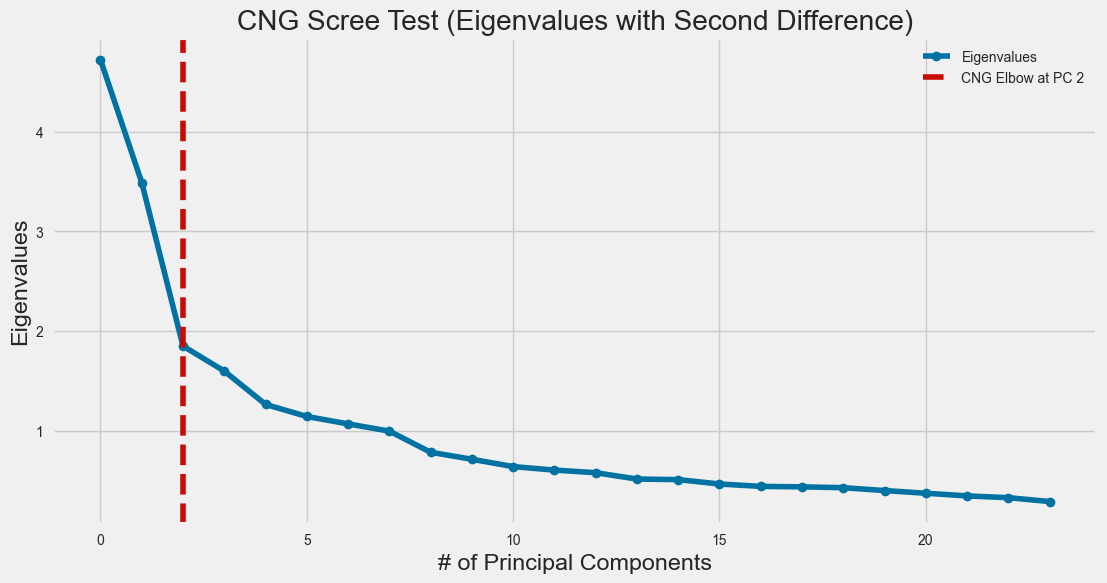

Optimal number of principal components (CNG elbow point): PC2


In [44]:
# Fit PCA model
pca = PCA(n_components=len(scaled_ds.columns))  # Number of components equals the number of features
pca.fit(scaled_ds)

# Get the eigenvalues (explained variance)
eigenvalues = pca.explained_variance_

# Calculate the first differences (change between consecutive eigenvalues)
first_diff = np.diff(eigenvalues)

# Calculate the second differences (change in first differences)
second_diff = np.diff(first_diff)

# Find the index of the largest second difference (this is our CNG elbow point)
cng_elbow_index = np.argmax(second_diff) + 1  # +1 because np.diff reduces length by 1

# Plotting the results
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the eigenvalues (Scree plot)
ax.plot(eigenvalues, marker='o', linestyle='-', color='b', label='Eigenvalues')

# Add the CNG elbow line
ax.axvline(x=cng_elbow_index, color='r', linestyle='--', label=f'CNG Elbow at PC {cng_elbow_index}')

# Set labels and title
ax.set_ylabel('Eigenvalues')
ax.set_xlabel('# of Principal Components')
ax.set_title('CNG Scree Test (Eigenvalues with Second Difference)')

# Show the legend
ax.legend(loc='best')

plt.show()

# Print the optimal number of components based on CNG scree test
print(f"Optimal number of principal components (CNG elbow point): PC{cng_elbow_index}")

https://sanchitamangale12.medium.com/scree-plot-733ed72c8608

In [73]:
pca = PCA(n_components=7)
scaled_ds_9D = pca.fit_transform(scaled_ds)
mat = pd.DataFrame(scaled_ds_9D)
mat2 = pd.DataFrame(scaled_ds_9D)

In [102]:
pca = PCA(n_components=2)
scaled_ds_9D = pca.fit_transform(scaled_ds)
mat = pd.DataFrame(scaled_ds_9D, columns=["PC1", "PC2"])
mat2 = pd.DataFrame(scaled_ds_9D)

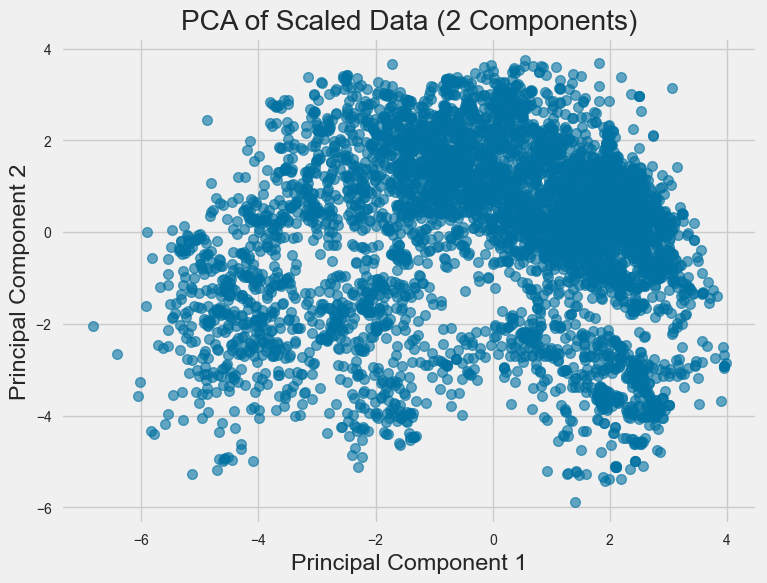

In [103]:
# --- Scatter Plot of PCA Components ---
plt.figure(figsize=(8, 6))

# Plot the points with PC1 and PC2
plt.scatter(mat['PC1'], mat['PC2'], color='b', alpha=0.6)

# Add labels and title
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Scaled Data (2 Components)')

# Optionally, add gridlines for better readability
plt.grid(True)

# Show the plot
plt.show()

Elbow Method to determine the number of clusters to be formed:


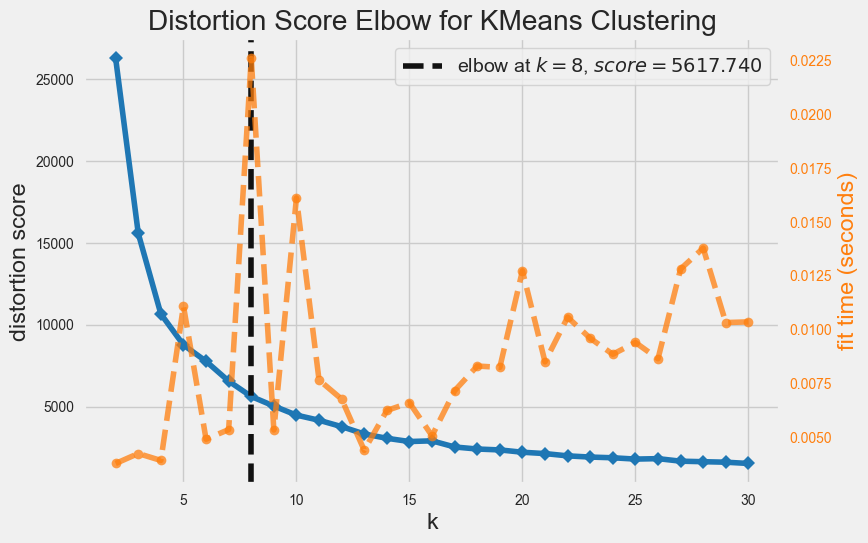

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [104]:
print('Elbow Method to determine the number of clusters to be formed:')
Elbow_M = KElbowVisualizer(KMeans(), k=30)
Elbow_M.fit(mat)
Elbow_M.show()

In [105]:
best_score = -1
best_n_clusters = 2

for n_clusters in range(2, 11):  # Try clusters from 2 to 10
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(mat)  # X is your dataset
    score = silhouette_score(mat, kmeans.labels_)
    print(f"For n_clusters = {n_clusters}, the average silhouette score is: {score}")

    if score > best_score:
        best_score = score
        best_n_clusters = n_clusters

print(f"The best number of clusters is: {best_n_clusters} with a silhouette score of {best_score}")

For n_clusters = 2, the average silhouette score is: 0.4039116461407995
For n_clusters = 3, the average silhouette score is: 0.4273841454028545
For n_clusters = 4, the average silhouette score is: 0.4418834674105732
For n_clusters = 5, the average silhouette score is: 0.39810392002211453
For n_clusters = 6, the average silhouette score is: 0.34215649141930177
For n_clusters = 7, the average silhouette score is: 0.3534143147881738
For n_clusters = 8, the average silhouette score is: 0.3606396752159141
For n_clusters = 9, the average silhouette score is: 0.3688970186982749
For n_clusters = 10, the average silhouette score is: 0.36781088994824784
The best number of clusters is: 4 with a silhouette score of 0.4418834674105732


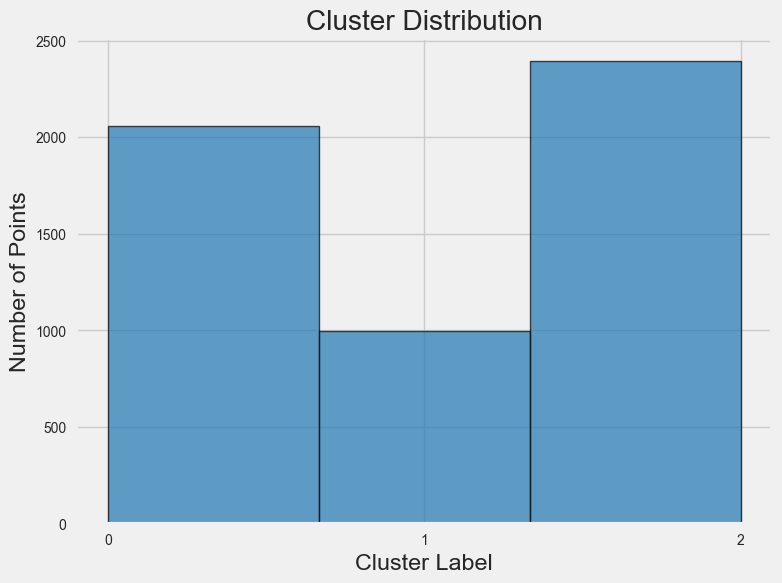

In [106]:
# Fit the KMeans model and assign cluster labels
kmeans = KMeans(init='k-means++', n_clusters=3, n_init=30, random_state=42)
kmeans.fit(mat)
clusters = kmeans.predict(mat)

# Add the cluster labels to the DataFrame
mat['cluster'] = pd.Series(clusters)

# Plot the histogram of the cluster labels
plt.figure(figsize=(8, 6))
plt.hist(mat['cluster'], bins=len(set(clusters)), edgecolor='black', alpha=0.7)
plt.title('Cluster Distribution')
plt.xlabel('Cluster Label')
plt.ylabel('Number of Points')
plt.xticks(range(0, len(set(clusters))))  # Ensure each cluster label is shown on x-axis
plt.show()

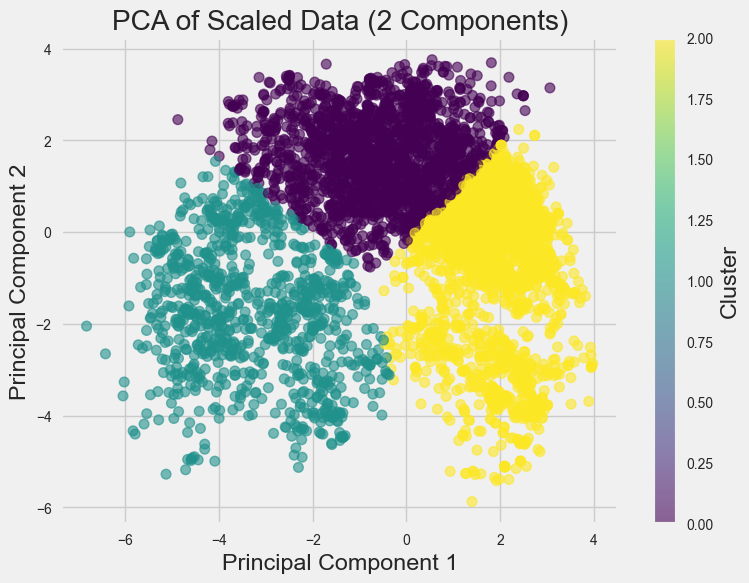

In [108]:
plt.figure(figsize=(8, 6))

# Plot the points with PC1 and PC2, using 'c' for color coding based on the cluster
plt.scatter(mat['PC1'], mat['PC2'], c=mat['cluster'], cmap='viridis', alpha=0.6)

# Add labels and title
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Scaled Data (2 Components)')

# Optionally, add gridlines for better readability
plt.grid(True)

# Show the plot
plt.colorbar(label='Cluster')  # Optional: Adds a color bar to indicate cluster labels
plt.show()

In [110]:
scaled_ds['cluster'] = clusters  # Add the cluster labels as a new column
df['cluster'] = clusters  # Add the cluster labels as a new column

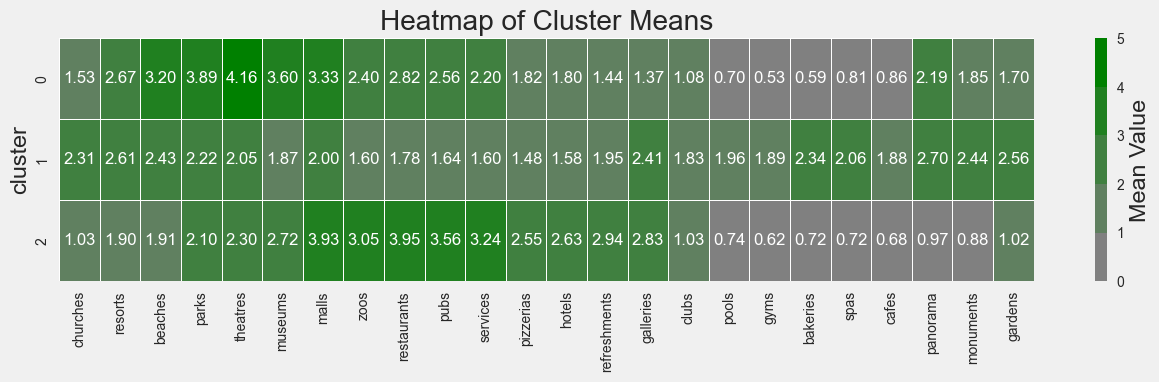

In [ ]:
from matplotlib.colors import BoundaryNorm, LinearSegmentedColormap

# Group by cluster and calculate the mean of each feature for each cluster
grouped_df = df.groupby('cluster').mean()

# Create a custom colormap from white to blue
white_blue_cmap = LinearSegmentedColormap.from_list("grey_to_blue", ["grey", "green"])

# Define the color boundaries for each range (adjust based on your data)
boundaries = [0, 1, 2, 3, 4, 5]  # Adjust this list based on your actual feature values
norm = BoundaryNorm(boundaries, white_blue_cmap.N)

# Create the heatmap with adjusted figure size
plt.figure(figsize=(14, 3))  # Adjust the figure size to make it more square-like

# Create the heatmap
sns.heatmap(grouped_df, cmap=white_blue_cmap, norm=norm, annot=True, fmt='.2f', linewidths=0.5, 
                 annot_kws={"size": 12}, cbar_kws={'label': 'Mean Value'})  # Adjust annotation size

# Display the heatmap
plt.title('Heatmap of Cluster Means')
plt.show()

In [ ]:
pca = PCA(n_components=2)
scaled_ds_2D = pca.fit_transform(scaled_ds)

# Step 2: Apply DBSCAN clustering
dbscan = DBSCAN(eps=0.5, min_samples=5)  # You may need to adjust eps and min_samples based on your dataset
dbscan_labels = dbscan.fit_predict(scaled_ds_2D)

# Add DBSCAN labels to the matrix
mat = pd.DataFrame(scaled_ds_2D, columns=['PC1', 'PC2'])
mat['dbscan_cluster'] = dbscan_labels  # Add cluster labels as a new column


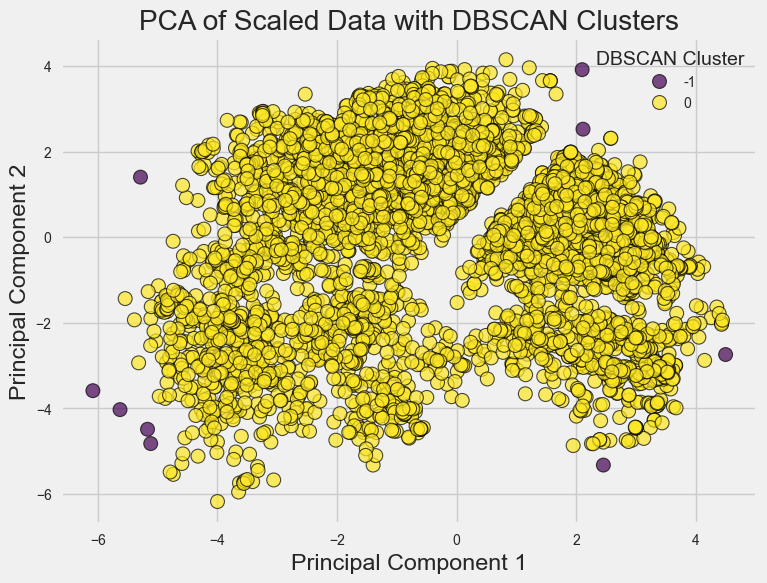

Unique DBSCAN clusters: [-1  0]


In [130]:
# Step 3: Plot the results (PCA components colored by DBSCAN clusters)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='dbscan_cluster', palette='viridis', data=mat, s=100, alpha=0.7, edgecolor='black')

# Customize plot labels and title
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA of Scaled Data with DBSCAN Clusters')

# Display the plot
plt.legend(title='DBSCAN Cluster')
plt.show()

# Optionally: Print the number of clusters found by DBSCAN
unique_clusters = np.unique(dbscan_labels)
print(f"Unique DBSCAN clusters: {unique_clusters}")

In [131]:
df['dbscan_cluster'] = dbscan_labels  # Add cluster labels as a new column

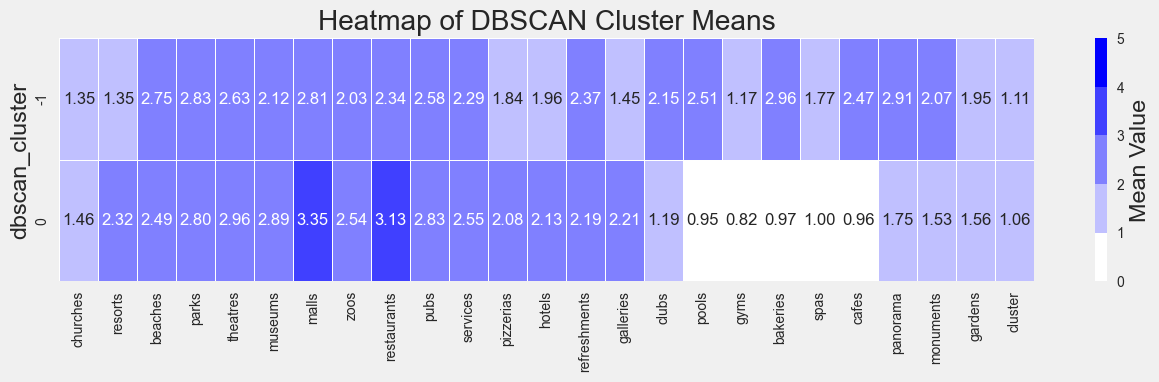

In [133]:
# Group by DBSCAN cluster and calculate the mean of each feature for each cluster
grouped_df = df.groupby('dbscan_cluster').mean()

# Create a custom colormap from white to blue
white_blue_cmap = LinearSegmentedColormap.from_list("white_to_blue", ["white", "blue"])

# Define the color boundaries for each range (adjust this based on your data)
boundaries = [0, 1, 2, 3, 4, 5]  # Adjust this list based on the actual feature values
norm = BoundaryNorm(boundaries, white_blue_cmap.N)

# Create the heatmap with adjusted figure size
plt.figure(figsize=(14, 3))  # Adjust the figure size to make it more square-like

# Create the heatmap
sns.heatmap(grouped_df, cmap=white_blue_cmap, norm=norm, annot=True, fmt='.2f', linewidths=0.5, 
            annot_kws={"size": 12}, cbar_kws={'label': 'Mean Value'})  # Adjust annotation size

# Display the heatmap
plt.title('Heatmap of DBSCAN Cluster Means')
plt.show()

# Approach 1

---------------------------------

In [2]:
s = (df.dtypes == 'object')
object_cols = list(s[s].index)

print("Categorical variables in the dataset:", object_cols)

NameError: name 'df' is not defined

In [58]:
LE=LabelEncoder()
for i in object_cols:
    data[i]=data[[i]].apply(LE.fit_transform)
    
print("All features are now numerical")

All features are now numerical


In [9]:
ds = df.copy()
cols_del = ['AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response']
ds = ds.drop(cols_del, axis=1, errors='ignore')
scaler = StandardScaler()
scaler.fit(ds)
scaled_ds = pd.DataFrame(scaler.transform(ds), columns=ds.columns)
print("All features are now scaled")

All features are now scaled


In [60]:
print("Dataframe to be used for further modelling:")
scaled_ds.head()

Dataframe to be used for further modelling:


,churches,resorts,beaches,parks,theatres,museums,malls,zoos,restaurants,pubs,...,galleries,clubs,pools,gyms,bakeries,spas,cafes,panorama,monuments,gardens
0,-1.758879,-1.632175,1.07158,0.847430,1.524728,0.020731,1.16655,-0.172031,-0.370937,-0.147413,...,0.117855,-0.737292,-0.517668,-1.405442,-0.353849,-1.342463,-1.686102,-2.589792,-1.925014,-2.245136
1,-1.758879,-1.632175,1.07158,0.847430,1.524728,0.020731,1.16655,0.088926,-0.370937,-0.139763,...,0.117855,-0.737292,-0.517668,-1.405442,-0.353849,-1.342463,-1.686102,-2.589792,-1.925014,-2.245136
2,-1.758879,-1.632175,1.07158,0.836078,1.524728,0.020731,1.16655,0.088926,-0.370937,-0.147413,...,0.117855,-0.737292,-0.517668,-1.405442,-0.353849,-1.342463,-1.686102,-2.589792,-1.925014,-2.245136
3,-1.758879,-1.280420,1.07158,0.836078,1.524728,0.020731,1.16655,-0.172031,-0.370937,-0.147413,...,0.117855,-0.737292,-0.517668,-1.405442,-0.353849,-1.342463,-1.686102,-2.589792,-1.925014,-2.245136
4,-1.758879,-1.632175,1.07158,0.836078,1.524728,0.020731,1.16655,0.088926,-0.370937,-0.147413,...,0.117855,-0.737292,-0.517668,-1.405442,-0.353849,-1.342463,-1.686102,-2.589792,-1.925014,-2.245136


In [61]:
pca = PCA(n_components=3)
pca.fit(scaled_ds)
PCA_ds = pd.DataFrame(pca.transform(scaled_ds), columns=(["col1","col2", "col3"]))
PCA_ds.describe().T

,count,mean,std,min,25%,50%,75%,max
col1,5454.0,-6.253401e-17,2.314736,-5.146020,-1.735073,-0.407117,1.514591,6.595975
col2,5454.0,5.211168e-17,1.925925,-5.975615,-1.219248,0.273146,1.311285,4.716300
col3,5454.0,-3.126701e-17,1.371309,-3.963915,-0.960074,-0.103220,0.995297,3.503931


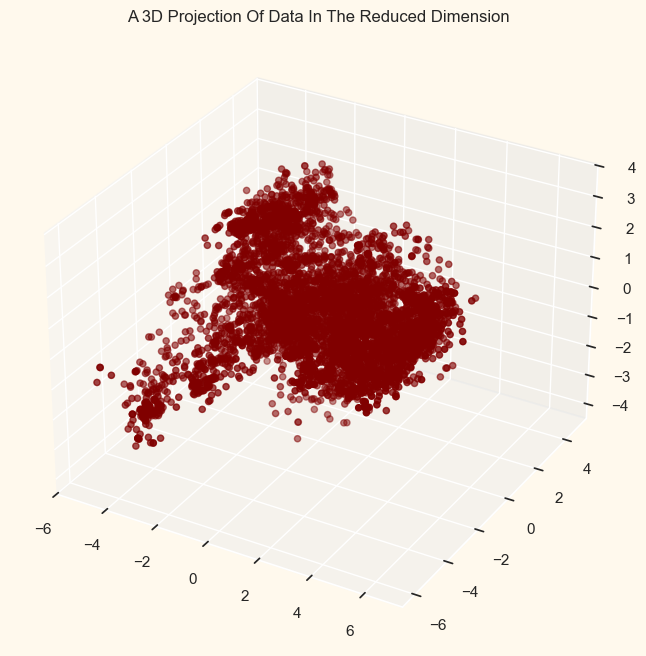

In [112]:
x =PCA_ds["col1"]
y =PCA_ds["col2"]
z =PCA_ds["col3"]
#To plot
fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(x,y,z, c="maroon", marker="o" )
ax.set_title("A 3D Projection Of Data In The Reduced Dimension")
plt.show()

Elbow Method to determine the number of clusters to be formed:


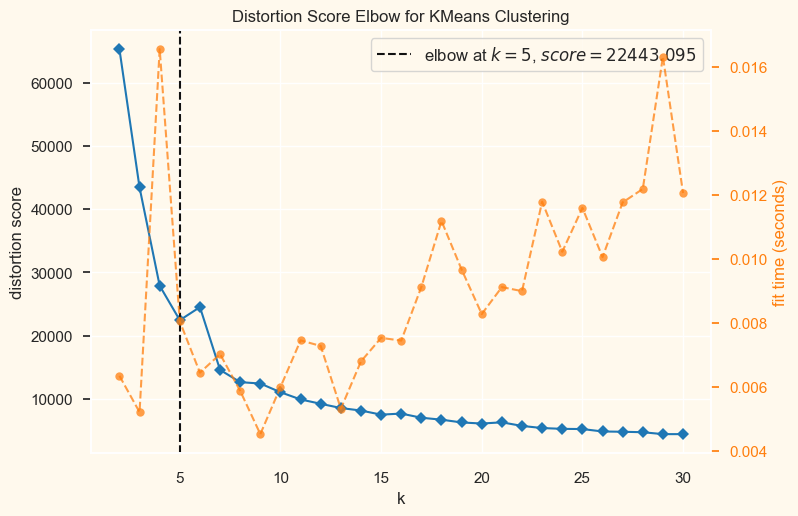

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [111]:
print('Elbow Method to determine the number of clusters to be formed:')
Elbow_M = KElbowVisualizer(KMeans(), k=30)
Elbow_M.fit(PCA_ds)
Elbow_M.show()

In [113]:
# Initiating the Agglomerative Clustering model 
AC = AgglomerativeClustering(n_clusters=8)
# Fit model and predict clusters
yhat_AC = AC.fit_predict(PCA_ds.drop(columns=["Clusters"]))
PCA_ds["Clusters"] = yhat_AC
# Adding the Clusters feature to the original dataframe
df["Clusters"] = yhat_AC

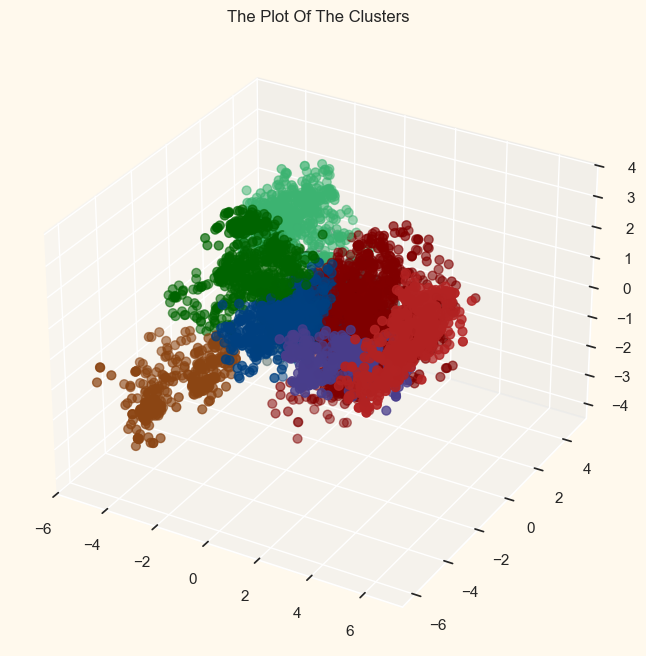

In [127]:

import matplotlib.colors as mcolors

# Define dark, distinct colors as a list (dark red, dark blue, etc.)
dark_colors = ["#800000", "#004080", "#006400", "#8B4513", "#800080", "#B22222", "#2F4F4F", "#3CB371", "#483D8B"]

# Create a colormap using the dark, distinct colors
cmap = mcolors.ListedColormap(dark_colors)

# Plotting 3D scatter
fig = plt.figure(figsize=(10, 8))
ax = plt.subplot(111, projection='3d', label="bla")

# Scatter plot with custom colormap
ax.scatter(x, y, z, s=40, c=PCA_ds["Clusters"], marker='o', cmap=cmap)

# Set title
ax.set_title("The Plot Of The Clusters")

# Show the plot
plt.show()


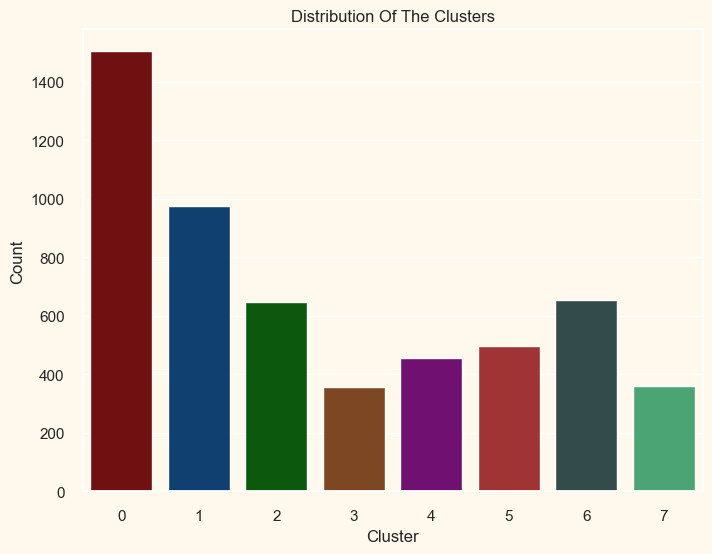

In [125]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define a custom set of dark, distinct colors
pal = ["#800000", "#004080", "#006400", "#8B4513", "#800080", "#B22222", "#2F4F4F", "#3CB371", "#483D8B"]

# Create the countplot with dark, distinct colors
plt.figure(figsize=(8, 6))
pl = sns.countplot(x=df["Clusters"], palette=pal)

# Set the title and labels
pl.set_title("Distribution Of The Clusters")
pl.set_xlabel("Cluster")
pl.set_ylabel("Count")

# Show the plot
plt.show()


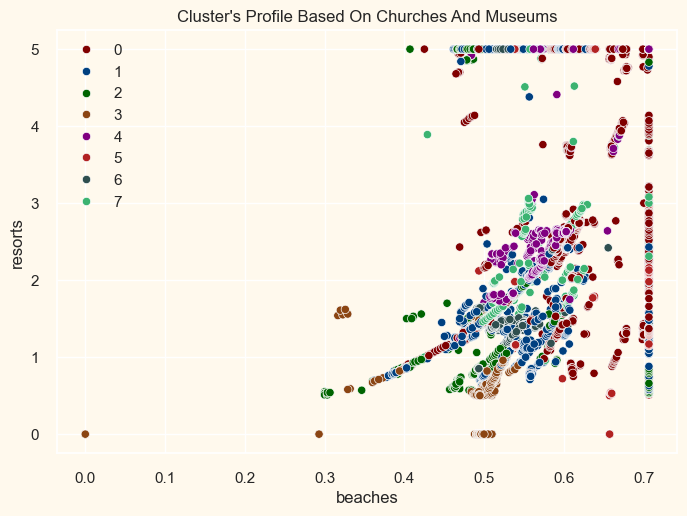

In [129]:
pl = sns.scatterplot(data=df, x="beaches", y="resorts", hue="Clusters", palette=pal)
pl.set_title("Cluster's Profile Based On Churches And Museums")
plt.legend()
plt.show()

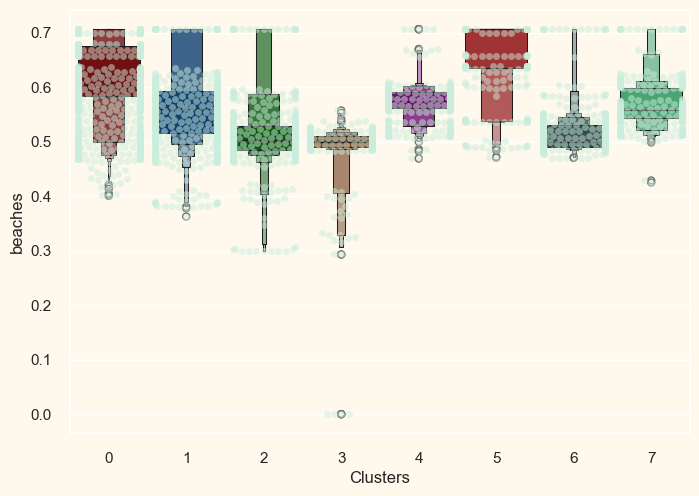

In [131]:
plt.figure()
pl = sns.swarmplot(x=df["Clusters"], y=df["beaches"], color="#CBEDDD", alpha=0.5)
pl = sns.boxenplot(x=df["Clusters"], y=df["beaches"], palette=pal)
plt.show()

# Approach 2

--------------------------

In [16]:
sns.boxplot(df)

<Axes: >

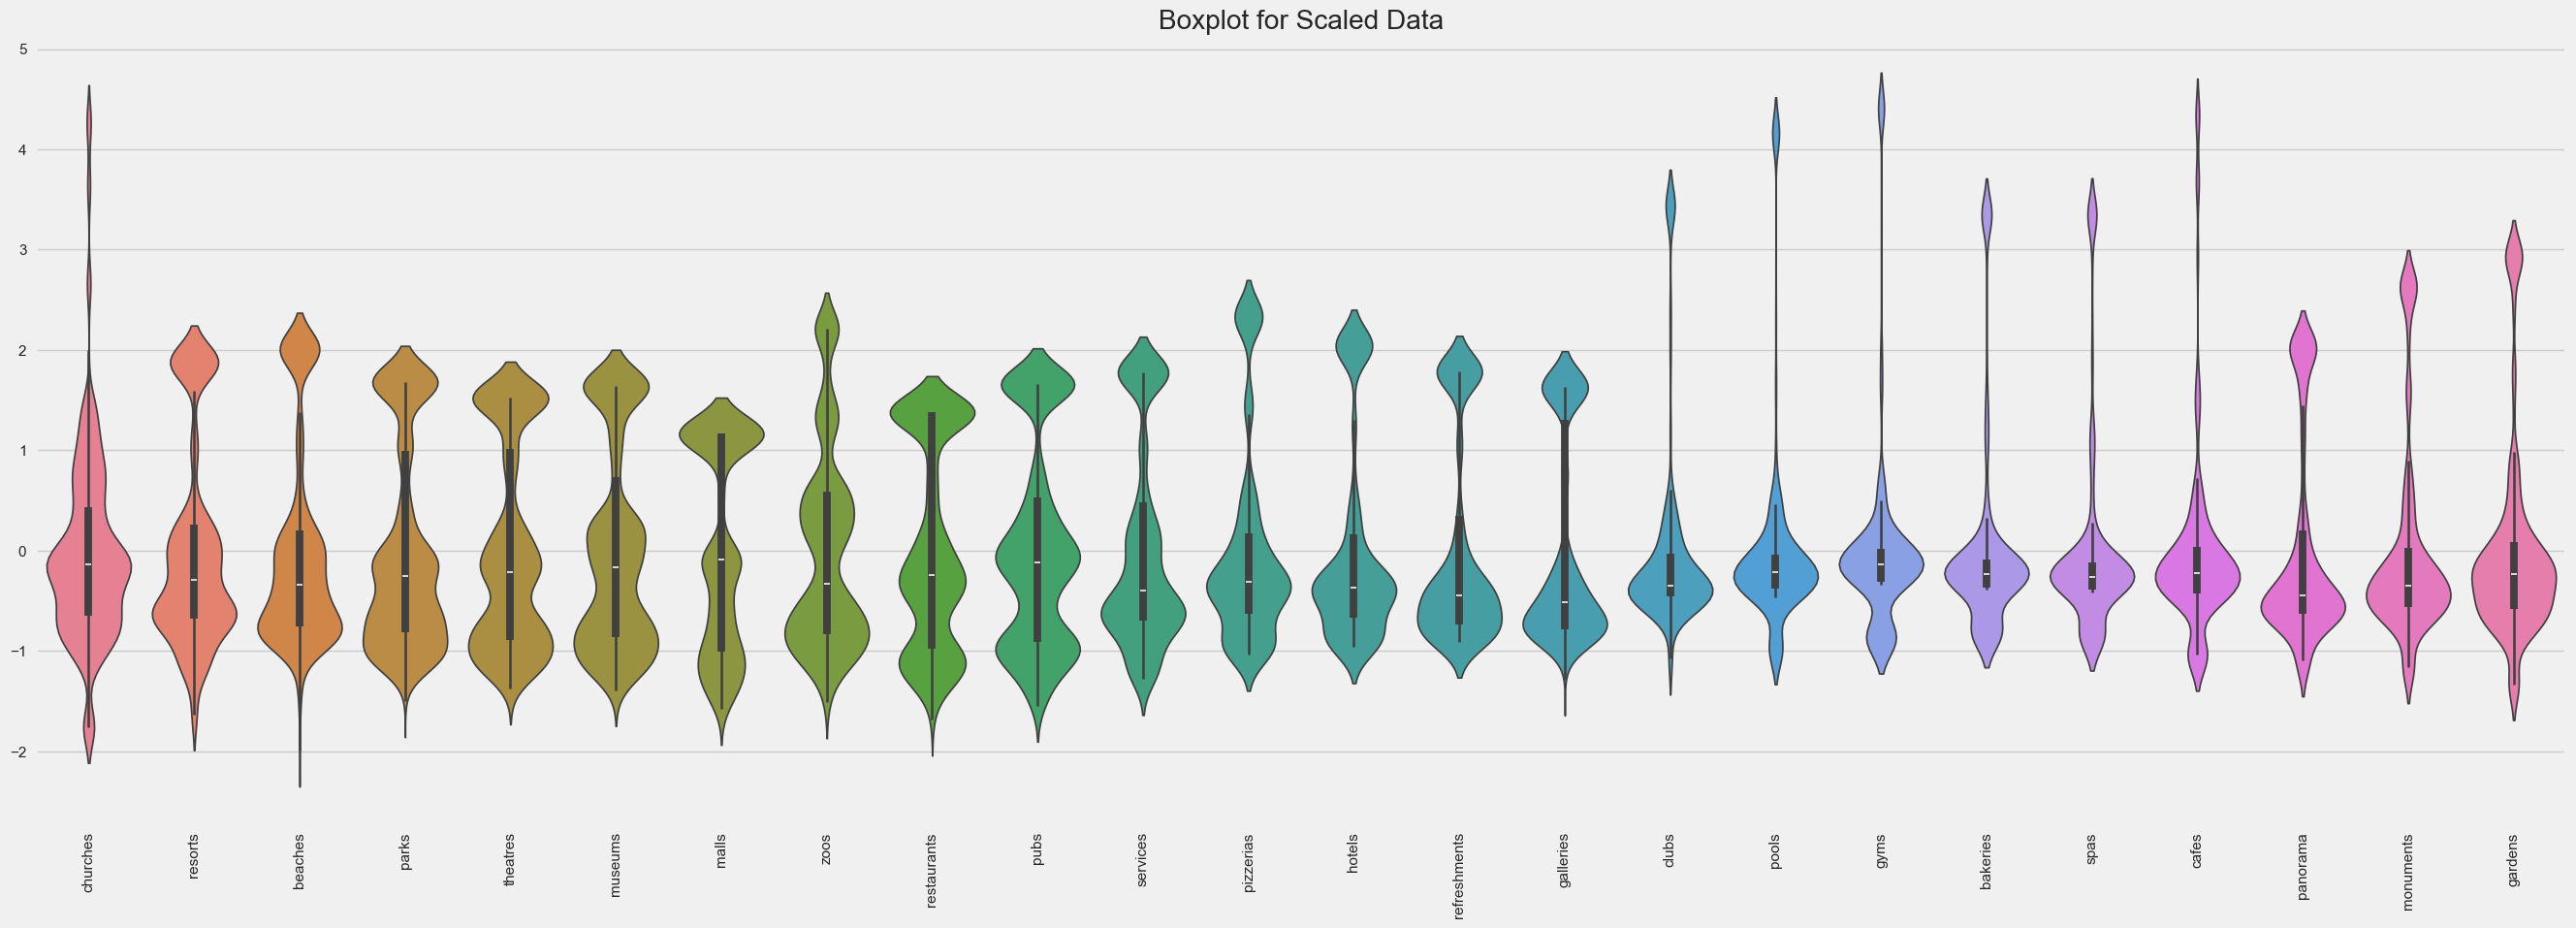

In [76]:
plt.figure(figsize=(30, 10))
sns.violinplot(data=scaled_ds)
plt.xticks(rotation=90)
plt.title('Boxplot for Scaled Data')
plt.show()


In [17]:
# Step 1: Calculate the IQR for each feature to detect outliers
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

# Step 2: Define lower and upper bounds to identify outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Step 3: Identify outliers in the DataFrame
outliers = (df < lower_bound) | (df > upper_bound)

In [18]:
df_no_outliers = df.copy()  # Create a copy to preserve the original
for column in df.columns:
    mean_value = df[column].mean()  # Calculate the mean of the column
    df_no_outliers[column] = df[column].mask(outliers[column], mean_value)

In [74]:
def remove_outliers(df, lower_bound, upper_bound):
    return df[~((df < lower_bound) | (df > upper_bound)).any(axis=1)]

# Iterate until the number of outliers doesn't change significantly
previous_shape = df.shape
for _ in range(5):  # Limit the iterations to avoid infinite loops
    # Calculate new outliers
    q1 = df.quantile(0.25)
    q3 = df.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # Remove outliers
    df_no_outliers = remove_outliers(df, lower_bound, upper_bound)
    
    # If the number of rows has not changed, break out of the loop
    if df_no_outliers.shape == previous_shape:
        break
    previous_shape = df_no_outliers.shape

print(f"Shape of dataframe after iterative outlier removal: {df_no_outliers.shape}")

Shape of dataframe after iterative outlier removal: (686, 24)


In [75]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
scaled_ds = pd.DataFrame(df_scaled, columns=df_no_outliers.columns)

In [70]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_no_outliers)
scaled_ds = pd.DataFrame(df_scaled, columns=df_no_outliers.columns)

In [ ]:
columns_to_windsorize = ["churches", "resorts", "beaches", "pizzerias", "clubs", "pools", "gyms", "bakeries", "spas", "cafes", "panorama", "monuments", "gardens"]

for col in columns_to_windsorize:
    scaled_ds[col] = winsorize(scaled_ds[col], limits=[0.05, 0.05])

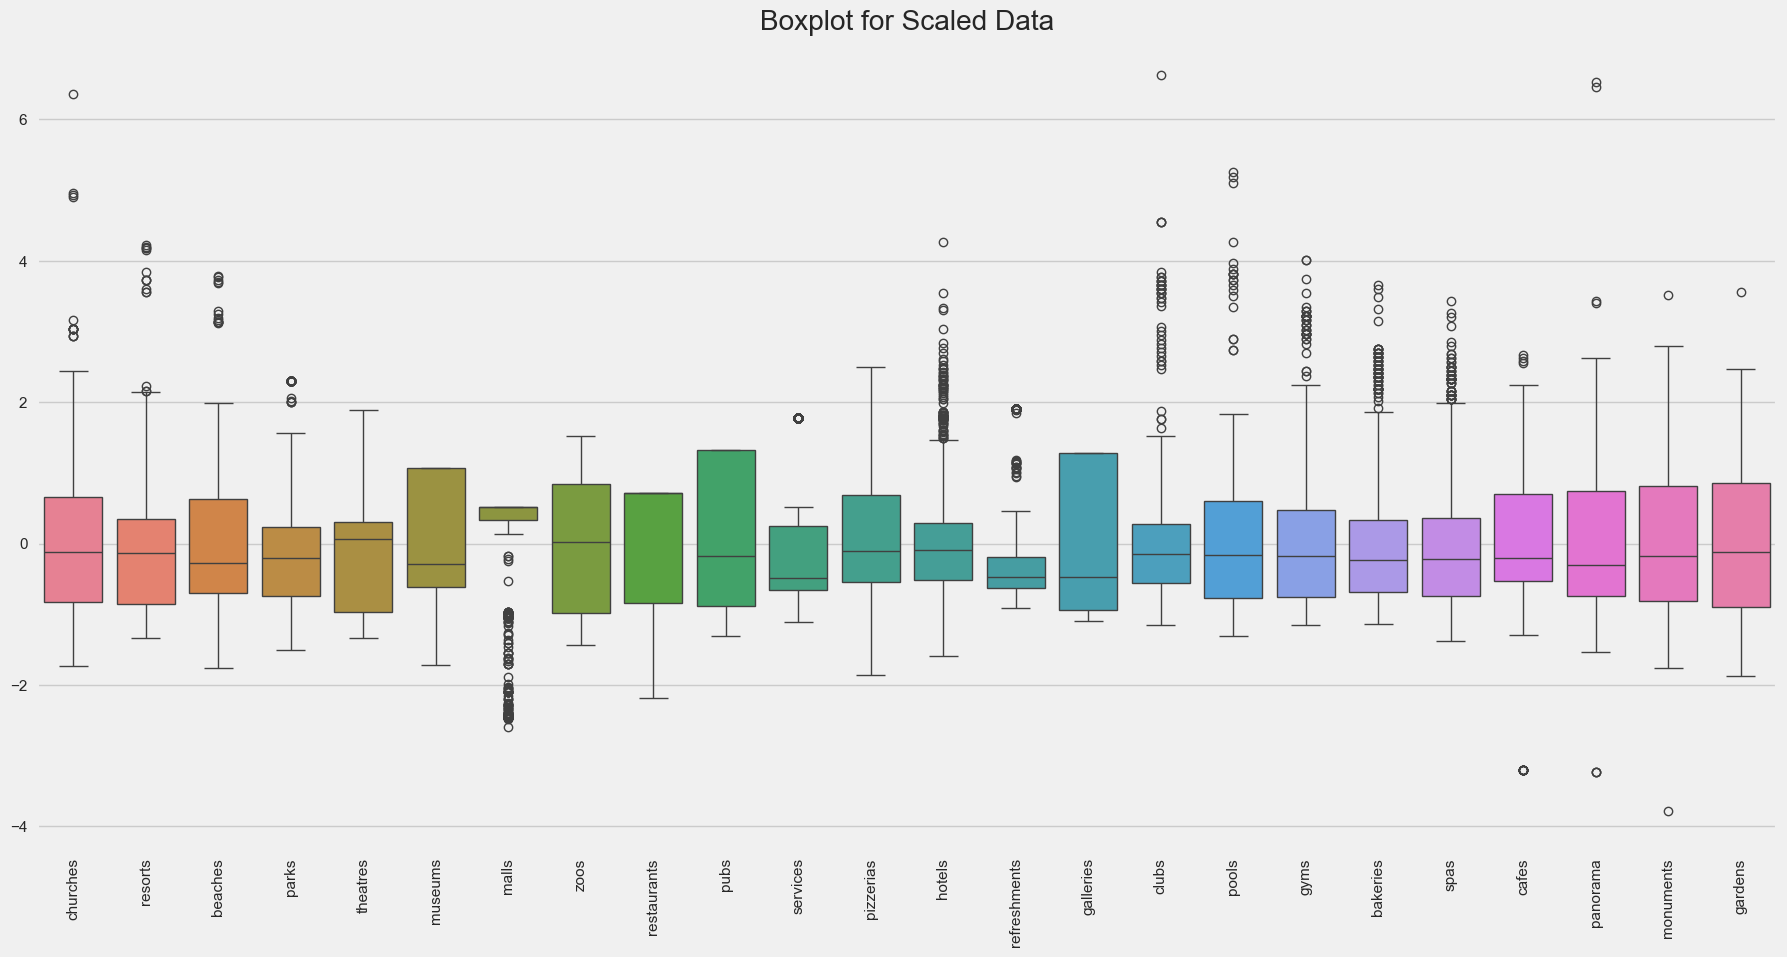

In [65]:
plt.figure(figsize=(20, 10))
sns.boxplot(data=scaled_ds)
plt.xticks(rotation=90)
plt.title('Boxplot for Scaled Data')
plt.show()

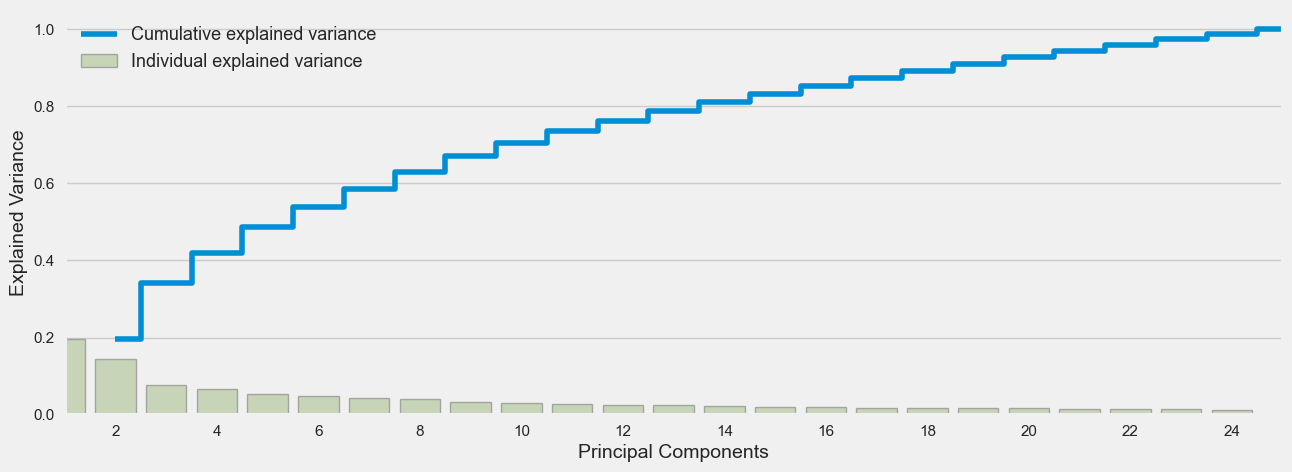

In [77]:
# PCA for variance explained plot
pca = PCA()
pca.fit(scaled_ds)
pca_samples = pca.transform(scaled_ds)

# Create the plot for explained variance
fig, ax = plt.subplots(figsize=(14, 5))

# Step plot for cumulative explained variance
plt.step(range(1, scaled_ds.shape[1] + 1), pca.explained_variance_ratio_.cumsum(), where='mid',
         label='Cumulative explained variance')

# Bar plot for individual explained variance
sns.barplot(x=np.arange(1, scaled_ds.shape[1] + 1), y=pca.explained_variance_ratio_, alpha=0.5, color='g',
            label='Individual explained variance')

# Set the x-axis limit based on the number of features (adjust if needed)
plt.xlim(0, scaled_ds.shape[1])

# Customize x-axis labels (hide odd-indexed labels)
ax.set_xticklabels([s if int(s.get_text()) % 2 == 0 else '' for s in ax.get_xticklabels()])

# Set labels and legend
plt.ylabel('Explained Variance', fontsize=14)
plt.xlabel('Principal Components', fontsize=14)
plt.legend(loc='upper left', fontsize=13)

# Show the plot
plt.show()

In [79]:
pca = PCA(n_components=8)
scaled_ds_9D = pca.fit_transform(scaled_ds)
mat = pd.DataFrame(scaled_ds_9D)
mat2 = pd.DataFrame(scaled_ds_9D)

In [80]:
mat.head()

,0,1,2,3,4,5,6,7
0,1.892708,1.603677,-2.050394,-0.441368,0.939278,-0.394691,-1.290342,-1.300091
1,1.964958,1.636942,-1.964057,-0.432715,0.941301,-0.327118,-1.246828,-1.275158
2,1.964424,1.631332,-1.962743,-0.436509,0.939944,-0.322917,-1.247982,-1.276329
3,1.860115,1.648980,-2.046756,-0.529698,0.903884,-0.399992,-1.040847,-1.265926
4,1.964424,1.631332,-1.962743,-0.436509,0.939944,-0.322917,-1.247982,-1.276329


Elbow Method to determine the number of clusters to be formed:


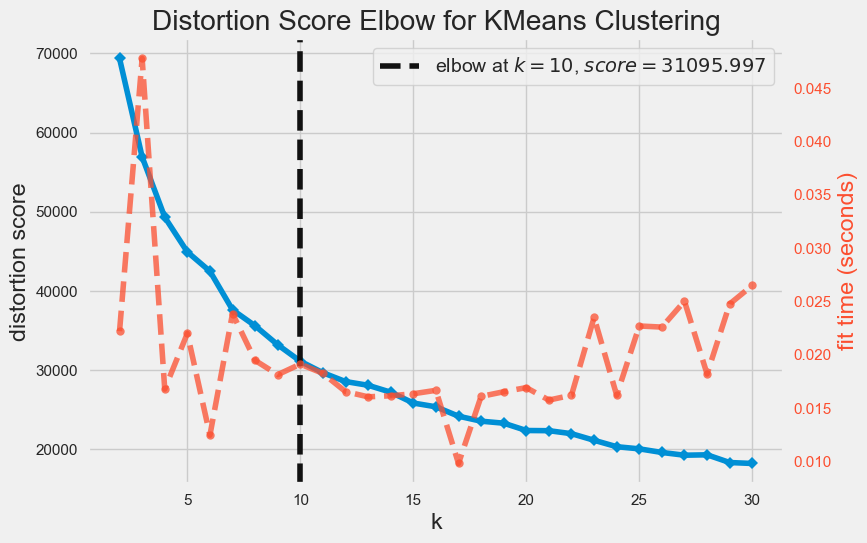

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [90]:
print('Elbow Method to determine the number of clusters to be formed:')
Elbow_M = KElbowVisualizer(KMeans(), k=30)
Elbow_M.fit(mat)
Elbow_M.show()

In [91]:
n_clusters = 10
silhouette_avg = -1
while silhouette_avg < 0.145:
    kmeans = KMeans(init='k-means++', n_clusters = n_clusters, n_init=30)
    kmeans.fit(mat)
    clusters = kmeans.predict(mat)
    silhouette_avg = silhouette_score(scaled_ds, clusters)
    
    #km = kmodes.KModes(n_clusters = n_clusters, init='Huang', n_init=2, verbose=0)
    #clusters = km.fit_predict(scaled_ds)
    #silhouette_avg = silhouette_score(scaled_ds, clusters)
    print("For n_clusters =", n_clusters, "The average silhouette_score is :", silhouette_avg)

For n_clusters = 10 The average silhouette_score is : 0.1456745839258974


In [92]:
pd.Series(clusters).value_counts()

5    791
1    687
2    625
8    624
0    547
7    541
4    516
6    507
9    375
3    241
Name: count, dtype: int64

In [93]:
mat['cluster'] = pd.Series(clusters)

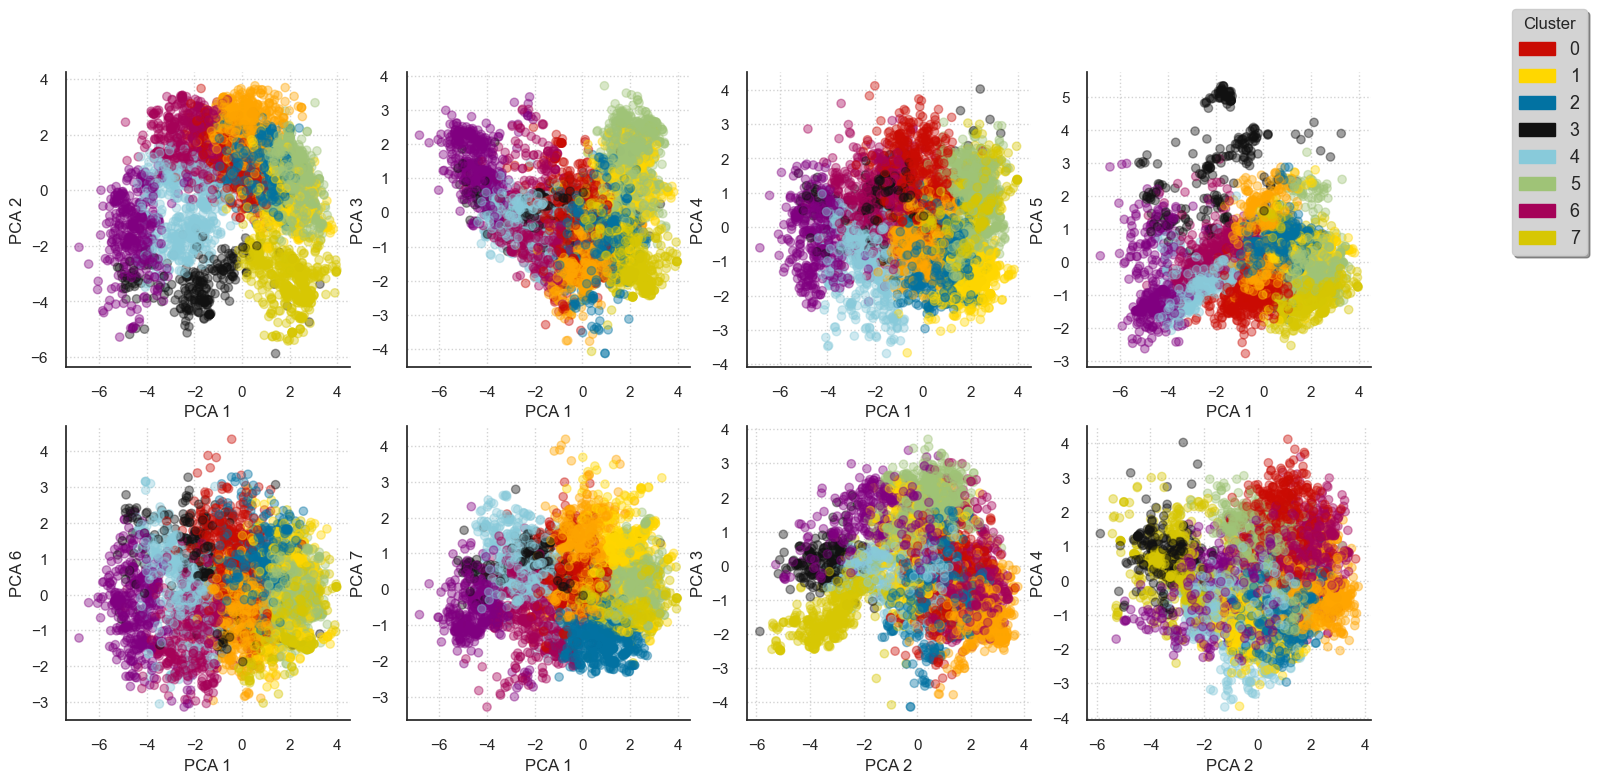

In [94]:
import matplotlib.patches as mpatches
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("white")
sns.set_context("notebook", font_scale=1, rc={"lines.linewidth": 2.5})

# Define color map for 15 clusters (adjusted for 15 clusters)
LABEL_COLOR_MAP = {
    0: 'r',       # red
    1: 'gold',    # gold
    2: 'b',       # blue
    3: 'k',       # black
    4: 'c',       # cyan
    5: 'g',       # green
    6: 'm',       # magenta
    7: 'y',       # yellow
    8: 'orange',  # orange
    9: 'purple',  # purple
    10: 'brown',  # brown
    11: 'pink',   # pink
    12: 'lime',   # lime green
    13: 'teal',   # teal
    14: 'navy'    # navy blue
}

label_color = [LABEL_COLOR_MAP[l] for l in mat['cluster']]

fig = plt.figure(figsize = (15,8))
increment = 0
for ix in range(7):
    for iy in range(ix+1, 7):    
        increment += 1
        ax = fig.add_subplot(2,4,increment)
        ax.scatter(mat[ix], mat[iy], c= label_color, alpha=0.4) 
        plt.ylabel('PCA {}'.format(iy+1), fontsize = 12)
        plt.xlabel('PCA {}'.format(ix+1), fontsize = 12)
        ax.yaxis.grid(color='lightgray', linestyle=':')
        ax.xaxis.grid(color='lightgray', linestyle=':')
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        
        if increment == 8: break
    if increment == 8: break
        
#_______________________________________________
# I set the legend: abreviation -> airline name
comp_handler = []
for i in range(8):
    comp_handler.append(mpatches.Patch(color = LABEL_COLOR_MAP[i], label = i))

plt.legend(handles=comp_handler, bbox_to_anchor=(1.1, 0.97), 
           title='Cluster', facecolor = 'lightgrey',
           shadow = True, frameon = True, framealpha = 1,
           fontsize = 13, bbox_transform = plt.gcf().transFigure)

plt.show()

In [95]:
# KMeans clustering with silhouette score loop
n_clusters = 10
silhouette_avg = -1

# Loop until silhouette score is greater than a threshold (0.145)
while silhouette_avg < 0.145:
    kmeans = KMeans(init='k-means++', n_clusters=n_clusters, n_init=30)
    kmeans.fit(mat2)
    clusters = kmeans.predict(mat2)
    silhouette_avg = silhouette_score(mat2, clusters)
    
    print("For n_clusters =", n_clusters, "The average silhouette_score is :", silhouette_avg)

# Function to plot silhouette for each cluster
def graph_component_silhouette(n_clusters, lim_x, mat_size, sample_silhouette_values, clusters):
    plt.rcParams["patch.force_edgecolor"] = True
    plt.style.use('fivethirtyeight')
    mpl.rc('patch', edgecolor='dimgray', linewidth=1)

    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(8, 8)
    ax1.set_xlim([lim_x[0], lim_x[1]])
    ax1.set_ylim([0, mat_size + (n_clusters + 1) * 10])
    
    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[clusters == i]
        ith_cluster_silhouette_values.sort()
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        cmap = cm.get_cmap("Spectral")
        color = cmap(float(i) / n_clusters)
        
        ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                          facecolor=color, edgecolor=color, alpha=0.8)
        
        ax1.text(-0.03, y_lower + 0.5 * size_cluster_i, str(i), color='red', fontweight='bold',
                 bbox=dict(facecolor='white', edgecolor='black', boxstyle='round, pad=0.3'))
        
        y_lower = y_upper + 10

# Calculate silhouette sample values
sample_silhouette_values = silhouette_samples(mat2, clusters)

# Plot silhouette component graph
graph_component_silhouette(n_clusters, [-0.07, 0.33], len(mat2), sample_silhouette_values, clusters)


For n_clusters = 10 The average silhouette_score is : 0.24196324685381326


In [96]:
scaled_ds['cluster'] = clusters  # Add the cluster labels as a new column
df['cluster'] = clusters  # Add the cluster labels as a new column

In [97]:
df['cluster'].unique()

array([0, 6, 4, 5, 7, 9, 3, 2, 1, 8], dtype=int32)

## Labeling

----------------------

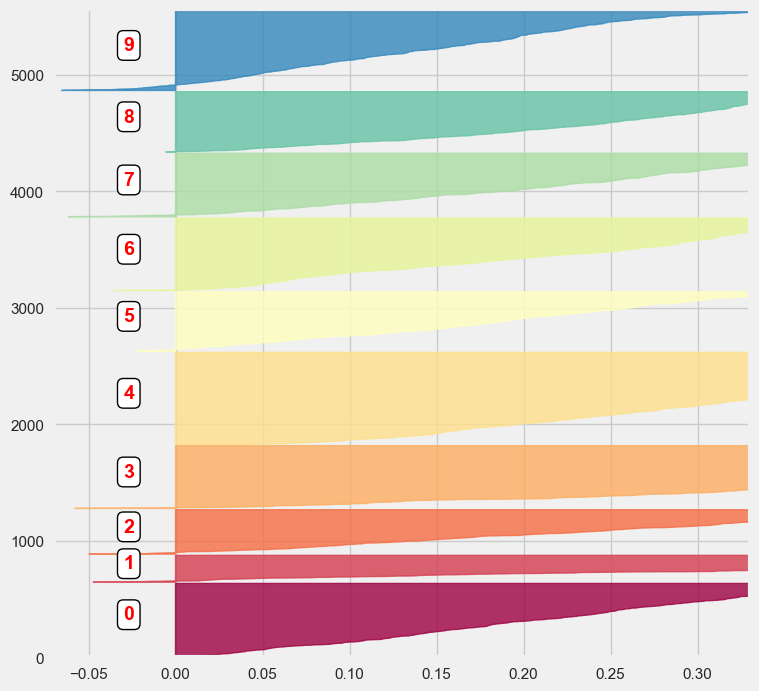

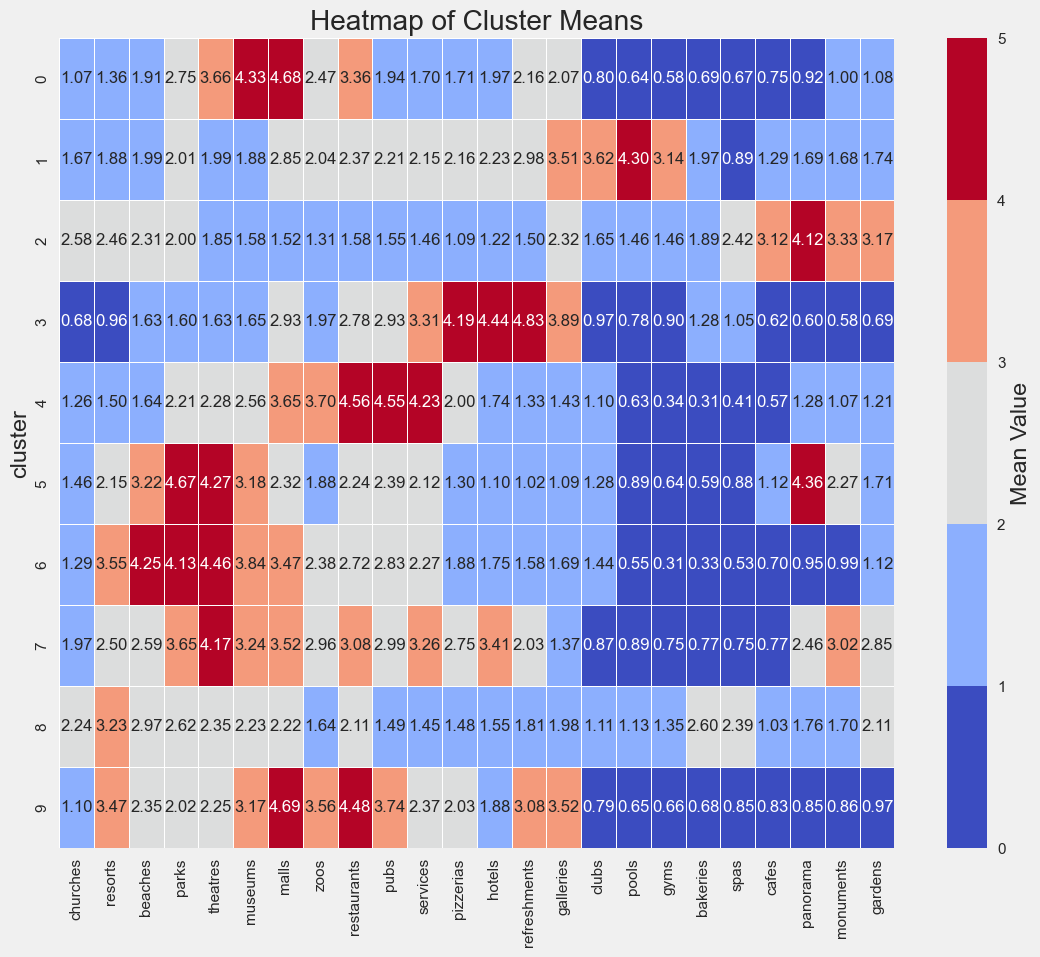

In [98]:

from matplotlib.colors import BoundaryNorm
from matplotlib import colors

grouped_df = df.groupby('cluster').mean()

# Define a custom color map with distinct colors for the specified ranges
cmap = sns.color_palette("coolwarm", as_cmap=True)

# Define the color boundaries for each range
boundaries = [0, 1, 2, 3, 4, 5]
norm = BoundaryNorm(boundaries, cmap.N)

# Create the heatmap with adjusted figure size
plt.figure(figsize=(12, 10))  # Increase the size to make the squares bigger

# Create the heatmap
sns.heatmap(grouped_df, cmap=cmap, norm=norm, annot=True, fmt='.2f', linewidths=0.5, 
            annot_kws={"size": 12}, cbar_kws={'label': 'Mean Value'})  # Adjust annotation size

# Display the heatmap
plt.title('Heatmap of Cluster Means')
plt.show()



In [ ]:
# Assuming df is your dataframe and 'cluster' is the column
cluster_map = {
    8: 'Party Goers',
    7: 'Connoisseur',
    6: 'Fast Foodies',
    5: 'Yuppies',
    4: 'Tourist',
    3: 'Neutrals',
    2: 'Shoppaholics',
    1: 'Upperclass',
    0: 'Leisures'
}

# Replace the cluster values with the corresponding names
df['cluster'] = df['cluster'].replace(cluster_map)

## Classification Methods

----------------------------------

In [99]:
columns = ['churches', 'resorts', 'beaches', 'parks', 'theatres', 'museums',
       'malls', 'zoos', 'restaurants', 'pubs', 'services', 'pizzerias',
       'hotels', 'refreshments', 'galleries', 'clubs', 'pools', 'gyms',
       'bakeries', 'spas', 'cafes', 'panorama', 'monuments', 'gardens']

X = scaled_ds[columns]
Y = scaled_ds['cluster']

Precision: 95.14 % 
Confusion matrix, without normalization


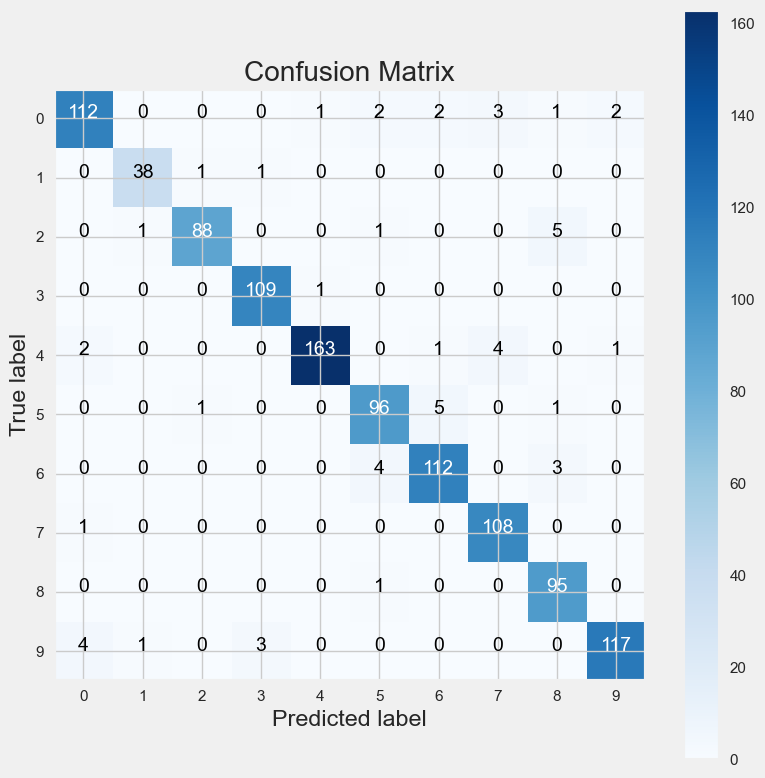

In [100]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, model_selection, metrics
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix
import itertools

# Define Class_Fit to include prediction storage
class Class_Fit(object):
    def __init__(self, clf, params=None):
        if params:
            self.clf = clf(**params)
        else:
            self.clf = clf()

    def train(self, x_train, y_train):
        self.clf.fit(x_train, y_train)

    def predict(self, x):
        return self.clf.predict(x)
    
    def grid_search(self, parameters, Kfold):
        self.grid = GridSearchCV(estimator=self.clf, param_grid=parameters, cv=Kfold)
        
    def grid_fit(self, X, Y):
        self.grid.fit(X, Y)
        
    def grid_predict(self, X, Y):
        self.predictions = self.grid.predict(X)
        print("Precision: {:.2f} % ".format(100 * metrics.accuracy_score(Y, self.predictions)))

# Splitting data
X_train, X_test, Y_train, Y_test = model_selection.train_test_split(X, Y, train_size=0.8)

# Model fitting and GridSearch
svc = Class_Fit(clf=svm.LinearSVC)
svc.grid_search(parameters=[{'C': np.logspace(-2, 2, 10)}], Kfold=5)
svc.grid_fit(X_train, Y_train)
svc.grid_predict(X_test, Y_test)

# Define confusion matrix plot function
def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')
    
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=0)
    plt.yticks(tick_marks, classes)
    
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")
    
    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Adjust class_names to match the actual number of clusters in Y
# Use np.unique to get the actual class labels from Y
class_names = [str(i) for i in np.unique(Y)]

# Generate confusion matrix
cnf_matrix = confusion_matrix(Y_test, svc.predictions) 

# Set precision for printout
np.set_printoptions(precision=2)

# Plot confusion matrix
plt.figure(figsize=(8, 8))
plot_confusion_matrix(cnf_matrix, classes=class_names, normalize=False, title='Confusion Matrix')
plt.show()


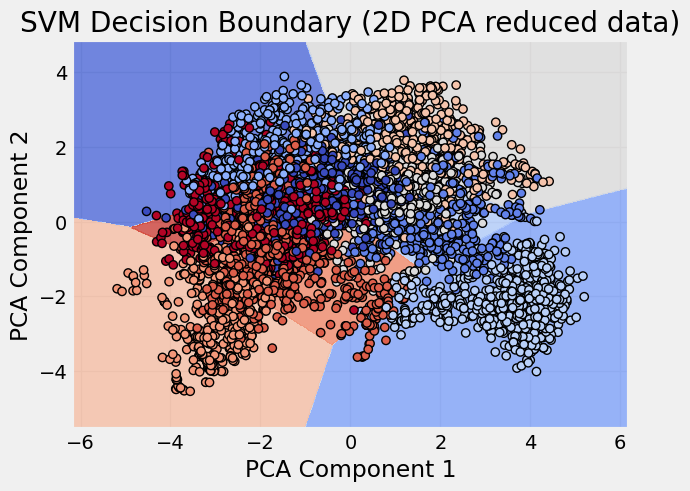

In [ ]:

from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split

# Assuming scaled_ds is already defined and contains the necessary data

# Column names for features
columns = ['churches', 'resorts', 'beaches', 'parks', 'theatres', 'museums',
           'malls', 'zoos', 'restaurants', 'pubs', 'services', 'pizzerias',
           'hotels', 'refreshments', 'galleries', 'clubs', 'pools', 'gyms',
           'bakeries', 'spas', 'cafes', 'panorama', 'monuments', 'gardens']

# Define X (features) and Y (target)
X = scaled_ds[columns]
Y = scaled_ds['cluster']

# 1. Reduce the dimensions of X to 2D using PCA for visualization
pca = PCA(n_components=2)
X_reduced = pca.fit_transform(X)

# 2. Split the data into training and testing sets
X_train, X_test, Y_train, Y_test = train_test_split(X_reduced, Y, train_size=0.8)

# 3. Train the SVM model using the reduced data
svc = LinearSVC(C=1.0)  # Simple SVM model without grid search for simplicity
svc.fit(X_train, Y_train)  # Fit the model with training data

# 4. Create a mesh grid to plot decision boundaries
h = .02  # step size in the mesh
x_min, x_max = X_reduced[:, 0].min() - 1, X_reduced[:, 0].max() + 1
y_min, y_max = X_reduced[:, 1].min() - 1, X_reduced[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# 5. Predict for each point in the mesh grid
Z = svc.predict(np.c_[xx.ravel(), yy.ravel()])  # Use the fitted model to predict
Z = Z.reshape(xx.shape)

# 6. Plot the decision boundary
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)

# 7. Plot the points
plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=Y, edgecolors='k', cmap=plt.cm.coolwarm)
plt.title("SVM Decision Boundary (2D PCA reduced data)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()


In [103]:
def plot_learning_curve(estimator, title, X, y, ylim=None, cv=None,
                        n_jobs=-1, train_sizes=np.linspace(.1, 1.0, 10)):
    """Generate a simple plot of the test and training learning curve"""
    plt.figure()
    plt.title(title)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.xlabel("Training examples")
    plt.ylabel("Score")
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=n_jobs, train_sizes=train_sizes)
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    plt.grid()

    plt.fill_between(train_sizes, train_scores_mean - train_scores_std,
                     train_scores_mean + train_scores_std, alpha=0.1, color="r")
    plt.fill_between(train_sizes, test_scores_mean - test_scores_std,
                     test_scores_mean + test_scores_std, alpha=0.1, color="g")
    plt.plot(train_sizes, train_scores_mean, 'o-', color="r", label="Training score")
    plt.plot(train_sizes, test_scores_mean, 'o-', color="g", label="Cross-validation score")

    plt.legend(loc="best")
    return plt

In [106]:
g = plot_learning_curve(svc.grid.best_estimator_,
                        "SVC learning curves", X_train, Y_train, ylim = [1.01, 0.6],
                        cv = 5,  train_sizes = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5,
                                                0.6, 0.7, 0.8, 0.9, 1])

Precision: 98.53 % 
Confusion matrix, without normalization


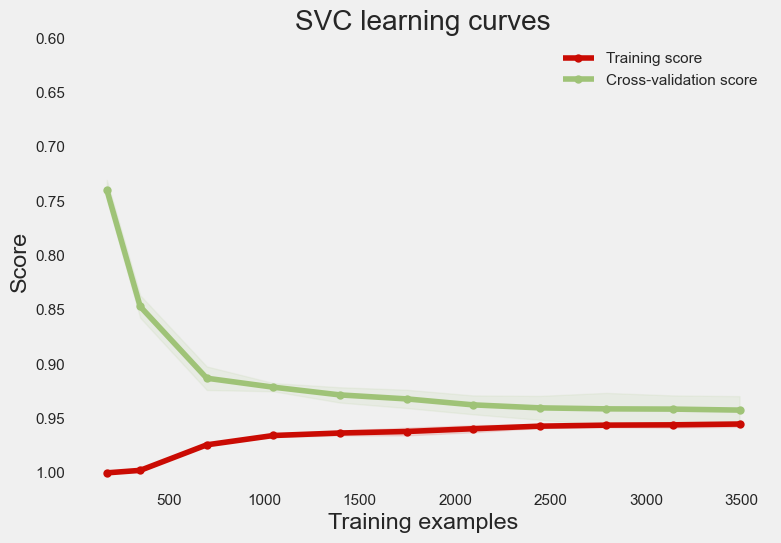

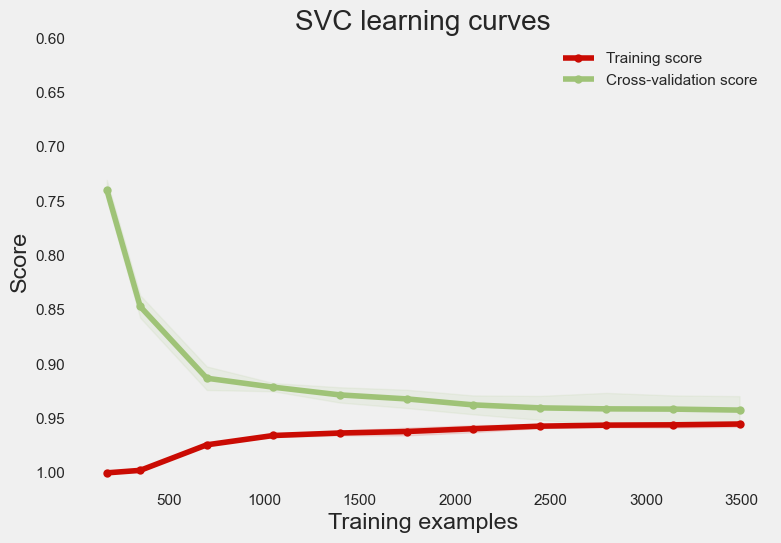

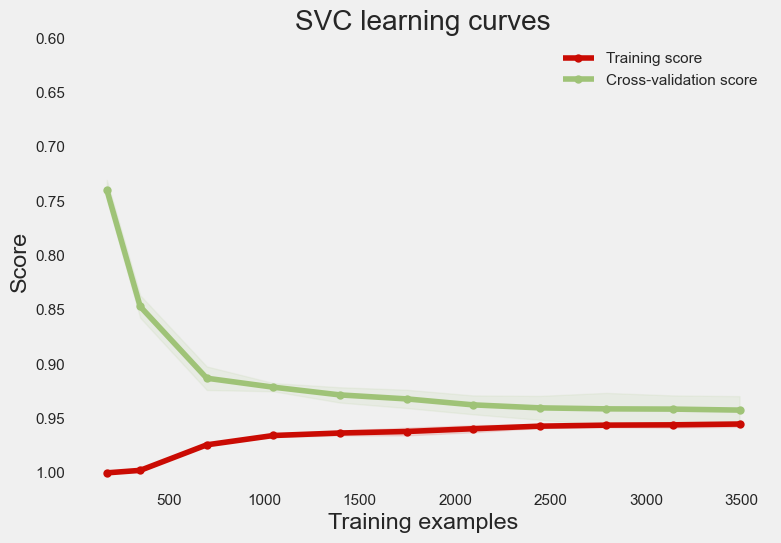

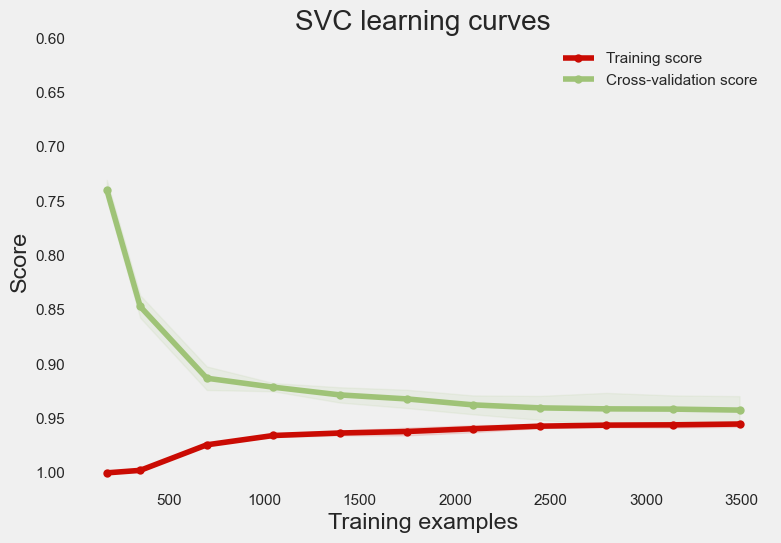

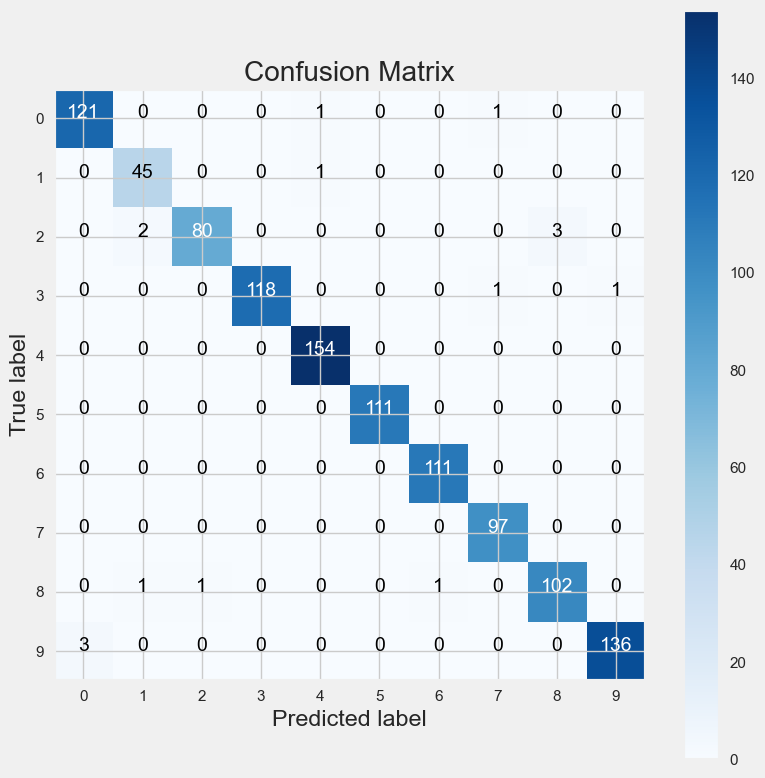

In [107]:
X_train, X_test, Y_train, Y_test = model_selection.train_test_split(X, Y, train_size=0.8)

# Logistic Regression model with grid search
lr = Class_Fit(clf = linear_model.LogisticRegression)

# Perform grid search for hyperparameter tuning
lr.grid_search(parameters = [{'C': np.logspace(-2, 2, 20)}], Kfold = 5)

# Fit the model
lr.grid_fit(X = X_train, Y = Y_train)

# Predict the test set
lr.grid_predict(X_test, Y_test)

# Now we will plot the confusion matrix

def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=0)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Generate confusion matrix
cnf_matrix = confusion_matrix(Y_test, lr.predictions)

# Assuming class names in the target variable Y are integer-based (adjust if categorical)
class_names = [str(i) for i in np.unique(Y)]

# Plot confusion matrix
plt.figure(figsize=(8, 8))
plot_confusion_matrix(cnf_matrix, classes=class_names, normalize=False, title='Confusion Matrix')
plt.show()



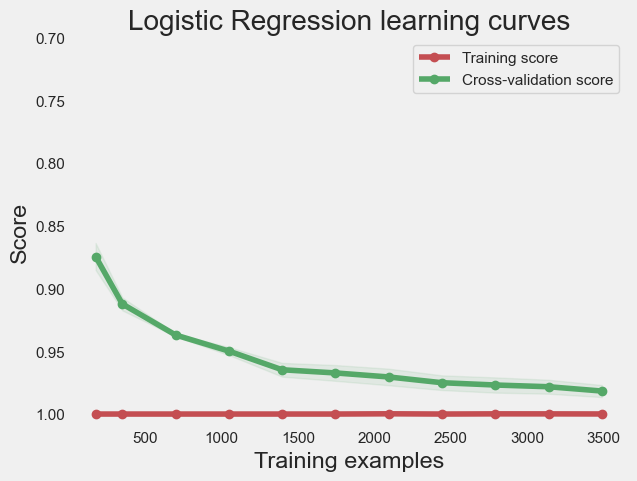

In [147]:
g = plot_learning_curve(lr.grid.best_estimator_, "Logistic Regression learning curves", X_train, Y_train,
                        ylim = [1.01, 0.7], cv = 5, 
                        train_sizes = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])

In [108]:
tr = Class_Fit(clf = tree.DecisionTreeClassifier)
tr.grid_search(parameters = [{'criterion' : ['entropy', 'gini'], 'max_features' :['sqrt', 'log2']}], Kfold = 5)
tr.grid_fit(X = X_train, Y = Y_train)
tr.grid_predict(X_test, Y_test)

Precision: 86.89 % 


Precision: 90.19 %
Confusion matrix, without normalization


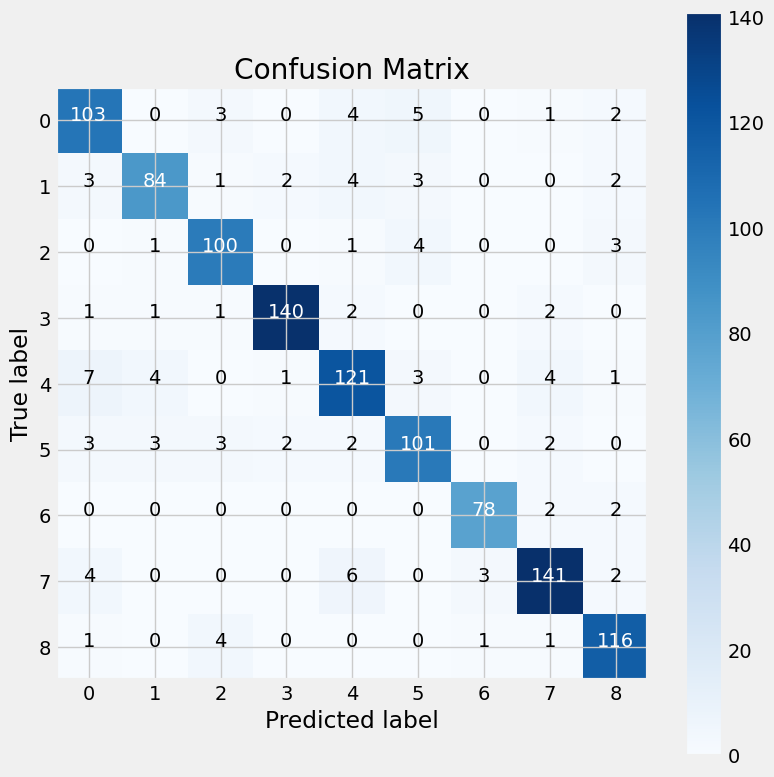

In [69]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import tree
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
import itertools
from sklearn.metrics import accuracy_score

# Assuming X and Y are your feature and target variables (adjust as necessary)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.8)

# Define the Class_Fit as per your original code
class Class_Fit(object):
    def __init__(self, clf, params=None):
        if params:
            self.clf = clf(**params)
        else:
            self.clf = clf()

    def train(self, x_train, y_train):
        self.clf.fit(x_train, y_train)

    def predict(self, x):
        return self.clf.predict(x)
    
    def grid_search(self, parameters, Kfold):
        self.grid = GridSearchCV(estimator=self.clf, param_grid=parameters, cv=Kfold)
        
    def grid_fit(self, X, Y):
        self.grid.fit(X, Y)
        
    def grid_predict(self, X, Y):
        self.predictions = self.grid.predict(X)
        print("Precision: {:.2f} %".format(100 * accuracy_score(Y, self.predictions)))

# Decision Tree Classifier with grid search
tr = Class_Fit(clf=tree.DecisionTreeClassifier)

# Perform grid search for hyperparameter tuning
tr.grid_search(parameters=[{'criterion': ['entropy', 'gini'], 'max_features': ['sqrt', 'log2']}], Kfold=5)

# Fit the model using training data
tr.grid_fit(X=X_train, Y=Y_train)

# Make predictions on the test set
tr.grid_predict(X_test, Y_test)

# Now we will plot the confusion matrix

def plot_confusion_matrix(cm, classes, normalize=False, title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=0)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Generate confusion matrix
cnf_matrix = confusion_matrix(Y_test, tr.predictions)

# Assuming class names in the target variable Y are integer-based (adjust if categorical)
class_names = [str(i) for i in np.unique(Y)]

# Plot confusion matrix
plt.figure(figsize=(8, 8))
plot_confusion_matrix(cnf_matrix, classes=class_names, normalize=False, title='Confusion Matrix')
plt.show()


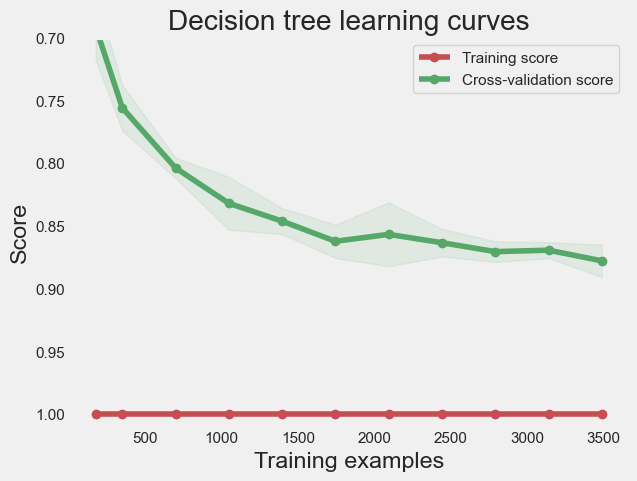

In [149]:
g = plot_learning_curve(tr.grid.best_estimator_, "Decision tree learning curves", X_train, Y_train,
                        ylim = [1.01, 0.7], cv = 5, 
                        train_sizes = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1])

Test